In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/bitimin_last

Mounted at /content/drive
/content/drive/MyDrive/bitimin_last


In [ ]:
import os

# 현재 작업 디렉토리(bitimin_last) 기준으로 상대 경로 사용
# 앞에 '/'를 붙이지 않아야 현재 위치 내부에 생성됩니다.
folder_path = "new_folder"

# 폴더 생성 (이미 있어도 에러 안 남)
os.makedirs(folder_path, exist_ok=True)ㄹ

# 절대 경로를 확인하고 싶다면 os.path.abspath 사용
print(f"폴더 생성 완료: {os.path.abspath(folder_path)}")

폴더 생성 완료: /content/drive/MyDrive/bitimin_last/new_folder


In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.1 MB/s eta 0:00:00


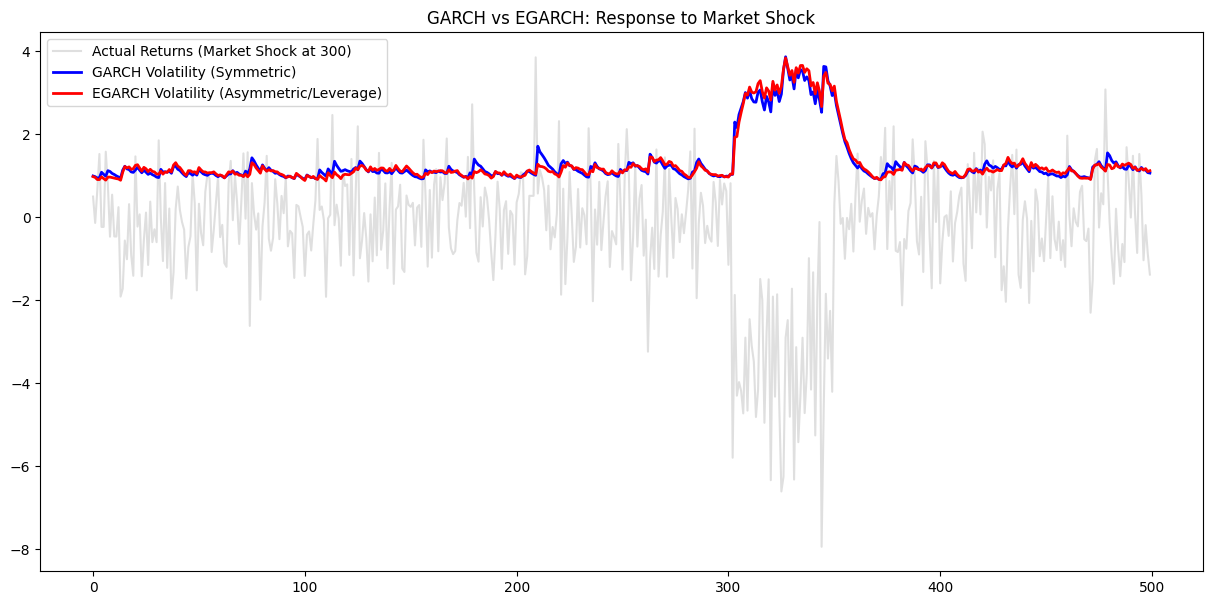

GARCH Residual Mean: -0.2894
EGARCH Residual Mean: -0.2576


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

# ==========================================
# 1) 가상 데이터 생성 (하락장 시나리오)
# ==========================================
np.random.seed(42)
n = 500
returns = np.random.normal(0, 1, n)

# 300~350 시점에 주가 폭락 발생 (악재 투하)
returns[300:350] = np.random.normal(-3, 2, 50)

# ==========================================
# 2) GARCH(1,1) 모델 학습
# ==========================================
# 대칭적 반응: 상승/하락 크기만 같으면 똑같이 반응
garch_m = arch_model(returns, vol='Garch', p=1, q=1, dist='normal')
res_garch = garch_m.fit(disp='off')

# ==========================================
# 3) EGARCH(1,1,1) 모델 학습
# ==========================================
# 비대칭적 반응: 하락(악재) 시 변동성을 가속함 (o=1 파라미터)
egarch_m = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='normal')
res_egarch = egarch_m.fit(disp='off')

# ==========================================
# 4) 결과 비교 시각화
# ==========================================
plt.figure(figsize=(15, 7))
plt.plot(returns, label='Actual Returns (Market Shock at 300)', color='silver', alpha=0.5)
plt.plot(res_garch.conditional_volatility, label='GARCH Volatility (Symmetric)', color='blue', lw=2)
plt.plot(res_egarch.conditional_volatility, label='EGARCH Volatility (Asymmetric/Leverage)', color='red', lw=2)

plt.title('GARCH vs EGARCH: Response to Market Shock')
plt.legend()
plt.show()

# 잔차(Residuals) 추출 비교
print(f"GARCH Residual Mean: {res_garch.resid.mean():.4f}")
print(f"EGARCH Residual Mean: {res_egarch.resid.mean():.4f}")

✅ 데이터 생성 및 로드 완료 (Size: (300, 3))


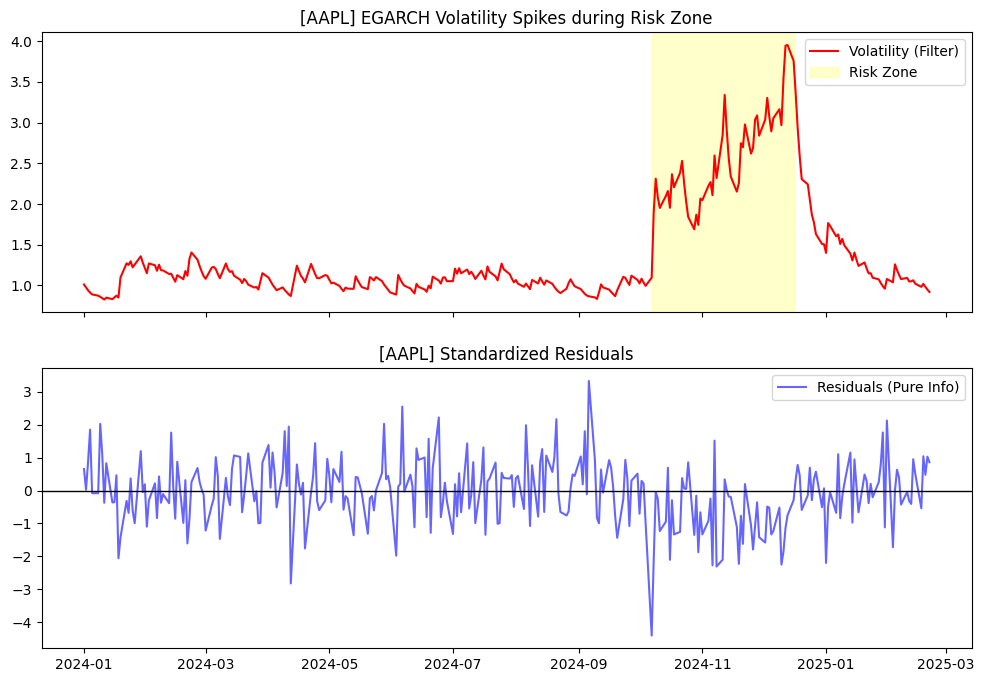

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# ==========================================
# 1) 코드 상에서 직접 데이터 생성 (Load 대신 Generate)
# ==========================================
def load_sample_data():
    np.random.seed(42)
    dates = pd.date_range(start="2024-01-01", periods=300, freq='B')

    # 세 종목의 수익률 생성 (AAPL, MSFT, NVDA 가정)
    data = {}
    for ticker in ['AAPL', 'MSFT', 'NVDA']:
        # 기본 변동성 (평상시)
        rets = np.random.normal(0, 0.01, 300)

        # 200~250 시점에 '시스템 리스크' 하락장 주입
        # 평균 하락폭은 -2.5%, 변동성(표준편차)은 3배 증가
        rets[200:250] = np.random.normal(-0.025, 0.03, 50)
        data[ticker] = rets

    df = pd.DataFrame(data, index=dates)
    return df

# 데이터 로드
df = load_sample_data()
print("✅ 데이터 생성 및 로드 완료 (Size: {})".format(df.shape))

# ==========================================
# 2) EGARCH 분석 함수 (이전과 동일)
# ==========================================
def analyze_vol_and_res(window_df, target_col='AAPL'):
    residuals_df = pd.DataFrame(index=window_df.index)
    volatility_df = pd.DataFrame(index=window_df.index)

    for col in window_df.columns:
        series = window_df[col] * 100 # % 단위 스케일링
        try:
            # EGARCH 모델 피팅
            res = arch_model(series, vol='EGARCH', p=1, o=1, q=1).fit(disp='off')
            volatility_df[col] = res.conditional_volatility
            residuals_df[col] = res.resid / res.conditional_volatility
        except:
            volatility_df[col], residuals_df[col] = np.nan, np.nan

    # 시각화
    fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    ax[0].plot(volatility_df[target_col], color='red', label='Volatility (Filter)')
    ax[0].set_title(f"[{target_col}] EGARCH Volatility Spikes during Risk Zone")
    ax[0].axvspan(df.index[200], df.index[250], color='yellow', alpha=0.2, label='Risk Zone')
    ax[0].legend()

    ax[1].plot(residuals_df[target_col], color='blue', alpha=0.6, label='Residuals (Pure Info)')
    ax[1].set_title(f"[{target_col}] Standardized Residuals")
    ax[1].axhline(0, color='black', lw=1)
    ax[1].legend()
    plt.show()

    return residuals_df, volatility_df

# 실행
res_df, vol_df = analyze_vol_and_res(df)

In [ ]:
!pip -q install yfinance pandas numpy tqdm
!pip install yfinance --upgrade --no-cache-dir


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.1/127.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 190.6 MB/s eta 0:00:00
  Attempting uninstall: curl_cffi
    Found existing installation: curl_cffi 0.14.0
    Uninstalling curl_cffi-0.14.0:
      Successfully uninstalled curl_cffi-0.14.0
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


In [ ]:
# import os
# import time
# import json
# import pandas as pd
# import numpy as np
# import yfinance as yf
# from tqdm import tqdm

# # =========================
# # 0) 설정
# # =========================
# # ETF들로 바꿔서 쓰기
# TICKERS = [
#     "SPY","GLD",
#     "QQQ",
#     "IWM",
#     "EEM",
#     "XLF", "XLK", "XLE", "XLV", "XLY", "XLP", "XLI", "XLU", "XLB",
#     "KRE", "TLT"
# ]
# # 10년 범위: 오늘 기준 '10y'로 받기 (원하면 start/end로 고정 가능)
# PERIOD = "10y"
# INTERVAL = "1d"  # 일봉

# OUT_DIR = "/content/drive/MyDrive/bitimin_last"
# os.makedirs(OUT_DIR, exist_ok=True)
# CHUNK_SIZE = 20


# etf정리 총 16개
1) 미국 대표 지수 ETF
- SPDR S&P 500 ETF Trust (SPY): S&P 500 추종
- Invesco QQQ Trust (QQQ): 나스닥100 추종(대형 기술주 비중 큼)
- iShares Russell 2000 ETF (IWM): 러셀2000 추종(미국 소형주)

2) 해외/이머징 ETF
- iShares MSCI Emerging Markets ETF (EEM): 신흥국(이머징) 주식

3) 미국 섹터 ETF (XL 시리즈: S&P 500 섹터)
- 금융: Financial Select Sector SPDR Fund (XLF)
- 기술: Technology Select Sector SPDR Fund (XLK)
- 에너지: Energy Select Sector SPDR Fund (XLE)
- 헬스케어: Health Care Select Sector SPDR Fund (XLV)
- 경기소비재(소비재-경기민감): Consumer Discretionary Select Sector SPDR Fund (XLY)
- 필수소비재(방어): Consumer Staples Select Sector SPDR Fund (XLP)

- 산업재: Industrial Select Sector SPDR Fund (XLI)
- 유틸리티(방어): Utilities Select Sector SPDR Fund (XLU)
- 소재: Materials Select Sector SPDR Fund (XLB)

4) 금융(세부 테마)
- SPDR S&P Regional Banking ETF (KRE): 미국 지역은행 중심(금리/신용 사이클에 민감)

5) 채권 ETF
- iShares 20+ Year Treasury Bond ETF (TLT): 미국 장기국채(20년+) → 금리 변동에 민감(듀레이션 김)

6) 원자재(금) ETF
- SPDR Gold Shares (GLD): 금 가격 추종(실물 금 보관 구조)

In [ ]:
# # =========================
# # 1) 가격(OHLCV) 일괄 다운로드
# # =========================
# def download_prices(tickers, period="10y", interval="1d"):
#     """
#     yfinance에서 여러 티커의 가격 데이터를 한 번에 받음.
#     반환: 컬럼명이 명시적인 DataFrame
#           예) Adj Close_SPY, Close_QQQ, Volume_IWM ...
#     """
#     df = yf.download(
#         tickers=tickers,
#         period=period,
#         interval=interval,
#         auto_adjust=False,   # Adj Close 유지
#         group_by="column",   # (price_type, ticker)
#         threads=True,
#         progress=False
#     )

#     # 인덱스(날짜) 정리
#     df.index = pd.to_datetime(df.index)

#     # 핵심: MultiIndex 컬럼 → 단일 컬럼명으로 변환
#     if isinstance(df.columns, pd.MultiIndex):
#         df.columns = [
#             f"{price}_{ticker}" for price, ticker in df.columns
#         ]

#     return df

# all_price_chunks = []
# ticker_chunks = [TICKERS[i:i+CHUNK_SIZE] for i in range(0, len(TICKERS), CHUNK_SIZE)]



# for chunk in tqdm(ticker_chunks, desc="Downloading price data (chunks)"):
#     df_chunk = download_prices(chunk, period=PERIOD, interval=INTERVAL)
#     all_price_chunks.append(df_chunk)
#     time.sleep(0.5)  # 가끔 rate-limit 완화용

# # 청크들 merge (컬럼 기준 합치기)
# prices = pd.concat(all_price_chunks, axis=1)
# prices.to_csv(os.path.join(OUT_DIR, f"etf_prices_{PERIOD}_{INTERVAL}.csv"))
# print("✅ Saved:", os.path.join(OUT_DIR, f"etf_prices_{PERIOD}_{INTERVAL}.csv"))


# # =========================
# # 수익률 계산 예시: Adj Close 기반 로그수익률
# # =========================

# # 🔹 Adj Close 컬럼들만 자동 선택
# adj_cols = [c for c in prices.columns if c.startswith("Adj Close_")]

# if not adj_cols:
#     raise ValueError("No 'Adj Close_' columns found in prices")

# # 🔹 Adj Close 데이터만 추출
# # adj = prices[adj_cols].copy()

# # 🔹 로그수익률 계산
# logret = np.log(adj / adj.shift(1))

# # 🔹 저장
# logret.to_csv(os.path.join(OUT_DIR, f"etf_log_returns_{PERIOD}.csv"))
# print("✅ Saved:", os.path.join(OUT_DIR, f"etf_log_returns_{PERIOD}.csv"))

# print("\nDone. Files in:", OUT_DIR)
# print(os.listdir(OUT_DIR))




✅ Saved: /content/drive/MyDrive/bitimin_last/etf_prices_10y_1d.csv
✅ Saved: /content/drive/MyDrive/bitimin_last/etf_log_returns_10y.csv

Done. Files in: /content/drive/MyDrive/bitimin_last
['.ipynb_checkpoints', 'etf_log_returns_10y.csv', 'etf_prices_10y_1d.csv']


# 개별 주식


In [ ]:
import os
import time
import pandas as pd
import numpy as np
import yfinance as yf
from tqdm import tqdm

# =========================
# 0) 설정 (89개 종목 리스트)
# =========================
TICKERS = [
    # 1. 정보기술 (Information Technology) - 12종목
    "AAPL", "MSFT", "NVDA", "AVGO", "ORCL", "ADBE", "CRM", "AMD", "CSCO", "ACN", "TXN", "INTC",

    # 2. 금융 (Financials) - 10종목
    "JPM", "BAC", "WFC", "GS", "MS", "V", "MA", "AXP", "BLK", "C",

    # 3. 경기소비재 (Consumer Discretionary) - 8종목
    "AMZN", "TSLA", "HD", "MCD", "NKE", "SBUX", "LOW", "BKNG",

    # 4. 커뮤니케이션 서비스 (Communication Services) - 6종목
    "GOOGL", "META", "NFLX", "DIS", "TMUS", "VZ",

    # 5. 헬스케어 (Health Care) - 10종목
    "LLY", "UNH", "JNJ", "ABBV", "MRK", "PFE", "TMO", "AMGN", "ISRG", "GILD",

    # 6. 필수소비재 (Consumer Staples) - 7종목
    "PG", "KO", "PEP", "COST", "WMT", "PM", "MO",

    # 7. 에너지 (Energy) - 6종목
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",

    # 8. 산업재 (Industrials) - 8종목
    "GE", "CAT", "UNP", "HON", "UPS", "BA", "LMT", "RTX",

    # 9. 소재 (Materials) - 5종목
    "LIN", "APD", "FCX", "SHW", "NEM",

    # 10. 유틸리티 (Utilities) - 4종목
    "NEE", "DUKE", "SO", "D",

    # 11. 부동산 (Real Estate) - 4종목
    "PLD", "AMT", "EQIX", "SPG"
]

PERIOD = "10y"
INTERVAL = "1d"
OUT_DIR = "/content/drive/MyDrive/bitimin_last"
os.makedirs(OUT_DIR, exist_ok=True)


In [ ]:

CHUNK_SIZE = 10

# =========================
# 1) 가격 다운로드 함수
# =========================
def download_stock_prices(tickers, period="10y", interval="1d"):
    df = yf.download(
        tickers=tickers,
        period=period,
        interval=interval,
        auto_adjust=False, # Adj Close 유지를 위해 False
        threads=True,
        progress=False
    )

    if isinstance(df.columns, pd.MultiIndex):
        df = df['Adj Close']

    return df

all_dfs = []
ticker_chunks = [TICKERS[i:i+CHUNK_SIZE] for i in range(0, len(TICKERS), CHUNK_SIZE)]

for chunk in tqdm(ticker_chunks, desc="Downloading Stock Data"):
    try:
        df_chunk = download_stock_prices(chunk, period=PERIOD, interval=INTERVAL)
        all_dfs.append(df_chunk)
        time.sleep(1.0)
    except Exception as e:
        print(f"❌ Error downloading {chunk}: {e}")

prices = pd.concat(all_dfs, axis=1)

# =========================
# 2) 전처리 (데이터 정렬 및 결측치 처리)
# =========================
threshold = len(prices) * 0.9
prices = prices.dropna(thresh=threshold, axis=1)
prices = prices.ffill().bfill()
prices = prices.dropna()

# 🔹 기존 코드와의 호환성을 위해 파일명 변경 저장
price_file_name = f"etf_prices_{PERIOD}_{INTERVAL}.csv"
prices.to_csv(os.path.join(OUT_DIR, price_file_name))

# =========================
# 3) 로그 수익률 계산 및 저장
# =========================
# log(0) 또는 log(음수) 방지를 위해 아주 작은 값(eps)을 고려할 수 있으나,
# 수정주가는 보통 양수이므로 dropna로 처리합니다.
log_returns = np.log(prices / prices.shift(1)).dropna()

# 무한대값 방어 코드 추가
log_returns.replace([np.inf, -np.inf], np.nan, inplace=True)
log_returns.fillna(0, inplace=True)

# 🔹 기존 코드와의 호환성을 위해 파일명 변경 저장
ret_file_name = f"etf_log_returns_{PERIOD}.csv"
log_returns.to_csv(os.path.join(OUT_DIR, ret_file_name))

print("-" * 30)
print(f"✅ 완료! 최종 종목 수: {len(log_returns.columns)}개")
print(f"✅ 저장 파일 1: {price_file_name}")
print(f"✅ 저장 파일 2: {ret_file_name}")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DUKE']: YFPricesMissingError('possibly delisted; no price data found  (period=10y) (Yahoo error = "No data found, symbol may be delisted")')


------------------------------
✅ 완료! 최종 종목 수: 79개
✅ 저장 파일 1: etf_prices_10y_1d.csv
✅ 저장 파일 2: etf_log_returns_10y.csv


In [ ]:
import pandas as pd
import os

# 파일 경로 설정
OUT_DIR = "/content/drive/MyDrive/bitimin_last"
price_file = os.path.join(OUT_DIR, "etf_prices_10y_1d.csv")
ret_file = os.path.join(OUT_DIR, "etf_log_returns_10y.csv")

def check_missing_values(file_path, label):
    if not os.path.exists(file_path):
        print(f"❌ 파일을 찾을 수 없습니다: {file_path}")
        return

    # 데이터 로드 (index_col=0 으로 수정)
    df = pd.read_csv(file_path, index_col=0)

    print(f"\n{'='*20} [{label}] 결측치 점검 {'='*20}")

    # 1. 전체 결측치 개수 요약
    null_counts = df.isnull().sum()
    total_nulls = null_counts.sum()

    if total_nulls == 0:
        print(f"✅ 모든 데이터가 깨끗합니다! (Total Nulls: 0)")
    else:
        print(f"⚠️ 총 {total_nulls}개의 결측치가 발견되었습니다.")

        # 2. 결측치가 있는 컬럼들만 출력
        cols_with_nulls = null_counts[null_counts > 0]
        if not cols_with_nulls.empty:
            print("\n[컬럼별 결측치 개수]")
            print(cols_with_nulls)

        # 3. 구체적인 결측치 위치(날짜 및 종목) 찾기
        print("\n[상세 결측치 위치 (최대 10개 출력)]")
        # 결측치가 있는 위치의 인덱스와 컬럼명을 추출
        null_indices = df.isna().stack()
        null_locations = null_indices[null_indices].index.tolist()

        for i, (date, ticker) in enumerate(null_locations[:10]):
            print(f" - {date} | 종목: {ticker}")

        if len(null_locations) > 10:
            print(f" ... 외 {len(null_locations) - 10}곳 더 있음")

# 실행
check_missing_values(price_file, "가격 데이터(Prices)")
check_missing_values(ret_file, "수익률 데이터(Log Returns)")


==================== [가격 데이터(Prices)] 결측치 점검 ====================
✅ 모든 데이터가 깨끗합니다! (Total Nulls: 0)

==================== [수익률 데이터(Log Returns)] 결측치 점검 ====================
✅ 모든 데이터가 깨끗합니다! (Total Nulls: 0)


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1) 데이터 로드 및 인덱스 설정 (병합)
df = pd.read_csv("etf_log_returns_10y.csv")

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
print(df.shape)

# 2) 전처리: 결측치 제거 및 정렬
# axis=0 행 제거, 인덱스 시간 타입 재확인
df = df.dropna(axis=0).sort_index()

# 3) 기초 통계 및 상태 확인 (필요한 것만 요약)
print(f"Final Data Shape: {df.shape}")
print(f"Date Range: {df.index.min()} ~ {df.index.max()}")
print(df.head(3)) # 제대로 로드됐는지 살짝 확인용

(2513, 79)
Final Data Shape: (2513, 79)
Date Range: 2016-02-12 00:00:00 ~ 2026-02-10 00:00:00
                AAPL       ACN      ADBE       AMD      AVGO       CRM  \
Date                                                                     
2016-02-12  0.003090  0.013502  0.022823 -0.016261  0.044971  0.007400   
2016-02-16  0.027804  0.023069  0.028417  0.000000  0.036955  0.000670   
2016-02-17  0.015199  0.021438  0.036961  0.037538  0.034567  0.061216   

                CSCO      MSFT      NVDA      ORCL  ...       UPS       AMT  \
Date                                                ...                       
2016-02-12  0.017273  0.016170  0.016854  0.019893  ...  0.022461  0.023742   
2016-02-16  0.028657  0.018770  0.047809  0.004492  ...  0.013380  0.009064   
2016-02-17  0.023711  0.025699  0.024521  0.025717  ... -0.002641 -0.003012   

                   D      EQIX       NEE       NEM       PLD       SHW  \
Date                                                             

In [ ]:
df.columns

Index(['AAPL', 'ACN', 'ADBE', 'AMD', 'AVGO', 'CRM', 'CSCO', 'MSFT', 'NVDA',
       'ORCL', 'AXP', 'BAC', 'GS', 'INTC', 'JPM', 'MA', 'MS', 'TXN', 'V',
       'WFC', 'AMZN', 'BKNG', 'BLK', 'C', 'HD', 'LOW', 'MCD', 'NKE', 'SBUX',
       'TSLA', 'ABBV', 'DIS', 'GOOGL', 'JNJ', 'LLY', 'META', 'NFLX', 'TMUS',
       'UNH', 'VZ', 'AMGN', 'COST', 'GILD', 'ISRG', 'KO', 'MRK', 'PEP', 'PFE',
       'PG', 'TMO', 'COP', 'CVX', 'EOG', 'GE', 'MO', 'MPC', 'PM', 'SLB', 'WMT',
       'XOM', 'APD', 'BA', 'CAT', 'FCX', 'HON', 'LIN', 'LMT', 'RTX', 'UNP',
       'UPS', 'AMT', 'D', 'EQIX', 'NEE', 'NEM', 'PLD', 'SHW', 'SO', 'SPG'],
      dtype='object')

In [ ]:
df.head()


,AAPL,ACN,ADBE,AMD,AVGO,CRM,CSCO,MSFT,NVDA,ORCL,...,UPS,AMT,D,EQIX,NEE,NEM,PLD,SHW,SO,SPG
Date,,,,,,,,,,,,,,,,,,,,,
2016-02-12,0.003090,0.013502,0.022823,-0.016261,0.044971,0.007400,0.017273,0.016170,0.016854,0.019893,...,0.022461,0.023742,-0.003909,0.035115,-0.002058,0.029124,0.013959,0.034769,-0.002918,0.011177
2016-02-16,0.027804,0.023069,0.028417,0.000000,0.036955,0.000670,0.028657,0.018770,0.047809,0.004492,...,0.013380,0.009064,0.003042,0.022286,0.006071,-0.048480,0.029771,0.008883,0.003750,0.015249
2016-02-17,0.015199,0.021438,0.036961,0.037538,0.034567,0.061216,0.023711,0.025699,0.024521,0.025717,...,-0.002641,-0.003012,0.008926,-0.002234,-0.008222,0.011336,0.008041,0.000811,-0.005421,0.004070
2016-02-18,-0.019138,-0.004961,-0.016259,0.005249,-0.028013,-0.028599,-0.001135,-0.004397,0.082543,0.000000,...,-0.000615,0.015084,-0.000287,-0.001171,0.025692,0.009217,0.005590,-0.017007,0.021511,0.011425
2016-02-19,-0.002288,0.004355,0.004213,0.000000,0.012513,0.007106,0.004530,-0.007115,0.013228,0.004086,...,-0.000924,-0.002059,-0.004166,0.030731,0.003667,-0.009217,-0.009067,0.002861,-0.006158,0.001003


# garch 함수

In [ ]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 50.9 MB/s eta 0:00:00


# pcorr 전처리


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from arch import arch_model # 추가 설치 필요: pip install arch
from scipy.stats import skew, kurtosis
import networkx as nx
from sklearn.preprocessing import StandardScaler

#import numpy as np
import pandas as pd
from arch import arch_model

def get_garch_residuals(window_df):
    """
    각 자산별로 GARCH(1,1)을 적용하여 변동성을 필터링합니다.
    """
    std_residuals = pd.DataFrame(index=window_df.index, columns=window_df.columns)
    cond_vol = pd.DataFrame(index=window_df.index, columns=window_df.columns)

    for col in window_df.columns:
        # rescale=True: 수익률에 적절한 값을 곱해 수렴 속도를 높임 (매우 중요)
        am = arch_model(window_df[col], vol='Garch', p=1, q=1, dist='normal', rescale=True)

        # 오류 수정: show_batch 삭제, disp='off'만 유지
        res = am.fit(disp='off')

        # 표준화된 잔차 추출 (rescale된 경우 원래 스케일로 복원됨)
        # res.resid / res.conditional_volatility
        std_residuals[col] = res.resid / res.conditional_volatility

        # 분석용 조건부 변동성 저장 (rescale=True 시 스케일링된 값이므로 조정 필요할 수 있음)
        # 하지만 통상적으로 상대적 크기 비교를 위해 그대로 사용해도 무방합니다.
        cond_vol[col] = res.conditional_volatility

    return std_residuals, cond_vol

def dynamic_partial_corr(std_res, ridge=1e-2):
    """
    GARCH 잔차를 기반으로 부분 상관관계를 계산합니다.
    """
    # GARCH 잔차의 상관계수 행렬 계산
    corr_matrix = std_res.corr().values
    corr_matrix = corr_matrix + ridge * np.eye(corr_matrix.shape[0])

    # Precision Matrix 추출
    try:
        prec = np.linalg.inv(corr_matrix)
    except np.linalg.LinAlgError:
        # 역행렬 계산 실패 시 pseudo-inverse 사용
        prec = np.linalg.pinv(corr_matrix)

    d = np.sqrt(np.diag(prec))
    pc = -prec / np.outer(d, d)
    np.fill_diagonal(pc, 1.0)
    return pc

In [ ]:
import networkx as nx

from scipy.stats import skew, kurtosis

def sparsify_threshold(A, threshold=0.15, sym=True, keep_self=False):
    """
    1단계: Threshold로 강한 연결 추출
    2단계: 연결이 하나도 없는 노드(degree=0)에 대해 가장 강한 k개 연결 보충
    """
    backup_k = 2
    N = A.shape[0]
    B = A.copy()
    np.fill_diagonal(B, 0.0)

    # [Step 1] Threshold 적용
    B_th = np.where(B >= threshold, B, 0.0)

    # [Step 2] 고립 노드 보충
    for i in range(N):
        if np.sum(B_th[i]) == 0: # 연결된 에지가 하나도 없다면
            # 해당 행에서 가장 값이 큰(상관관계가 높은) 인덱스 k개 추출
            backup_idx = np.argsort(B[i])[::-1][:backup_k]
            for idx in backup_idx:
                if B[i, idx] > 0: # 0보다 큰 값이 하나라도 있다면 연결
                    B_th[i, idx] = B[i, idx]

    # 대칭화 (무방향 그래프 유지)
    if sym:
        B_th = np.maximum(B_th, B_th.T)

    return B_th

def normalize_adj(A):
    """
    A: (N,N) with self-loops already included
    return: D^{-1/2} A D^{-1/2}
    """
    A = A.copy()
    deg = A.sum(axis=1)
    deg[deg == 0] = 1.0
    D_inv_sqrt = np.diag(1.0 / np.sqrt(deg))
    return D_inv_sqrt @ A @ D_inv_sqrt


def get_graph_centrality(A_bin):
    """
    A_bin: (N, N) 이진 인접 행렬
    return: (N, 2) 주요 중심성 지표 (Degree, Eigenvector)
    """
    G = nx.from_numpy_array(A_bin)

    # 1. Degree Centrality (연결된 선의 개수)
    deg_cent = np.array(list(nx.degree_centrality(G).values()))

    # 2. Eigenvector Centrality (중요한 놈과 얼마나 연결되었나)
    try:
        eig_cent = np.array(list(nx.eigenvector_centrality(G, max_iter=1000).values()))
    except:
        # 수렴하지 않을 경우 차선책으로 PageRank 또는 Zero 사용
        eig_cent = np.zeros(A_bin.shape[0])

    return np.stack([deg_cent, eig_cent], axis=1) # (N, 2)
def make_node_features_extended(window_df, sigma_df, centrality_features, past_k=5):
    """
    기존 피처에 '시장 대비 상대 수익률'과 '변동성 변화량'을 추가합니다.
    """
    # [기본] 단기/중기 수익률
    ret_5d = window_df.tail(5).sum(axis=0).values
    ret_20d = window_df.tail(20).sum(axis=0).values

    # [추가 1] 시장 대비 상대적 강도 (Relative Strength)
    # 시장 전체 평균 수익률 대비 해당 종목의 이격도
    market_avg_5d = np.mean(ret_5d)
    relative_ret_5d = ret_5d - market_avg_5d

    # [추가 2] 가격 위치 (현재가 vs 120일 평균 괴리율 - 코드 구현 추가)
    # 현재 가격이 장기 평균 대비 얼마나 떨어졌는지 (과매도 확인)
    # window_df가 로그 수익률이므로 누적 합산으로 추세 계산
    cum_ret = window_df.cumsum(axis=0)
    price_pos = (cum_ret.iloc[-1] - cum_ret.mean(axis=0)).values

    # [추가 3] GARCH Vol 및 Vol 변화율
    curr_vol = sigma_df.iloc[-1].values
    prev_vol = sigma_df.iloc[-5].values if len(sigma_df) >= 5 else curr_vol
    vol_change = (curr_vol - prev_vol) / (prev_vol + 1e-6)

    # (N, 6) 스택
    X_combined = np.stack([
        ret_5d,          # 단기 모멘텀
        ret_20d,         # 중기 추세
        relative_ret_5d, # 시장 대비 강도 (시스템 리스크 시 0으로 수렴하는 경향)
        price_pos,       # 장기 가격 위치
        curr_vol,        # 현재 변동성
        vol_change       # 변동성 가속도
    ], axis=1)

    # ✅ 최종 결합: (N, 6) + (N, 2) = (N, 8) 피처
    X_final = np.concatenate([X_combined, centrality_features], axis=1)

    return X_final

# ---- 슬라이싱 ----
W = 120
TOPK = 4
RIDGE = 5e-2
# EWMA_SPAN = 20
PAST_K = 5
MIN_STD = 1e-6

df = df.rename(columns=lambda c: c.replace("Adj Close_", "r_"))
tickers = df.columns.tolist()
N = len(tickers)

X_list, A_list, A_bin_list, end_dates = [], [], [], []

for end in range(W-1, len(df)):
    window_df = df.iloc[end-(W-1):end+1]  # (120,N)

    # 1) 전처리: z = r/sigma
    # sigma = ewma_vol_df(window_df, span=EWMA_SPAN, min_std=MIN_STD)
    # z_df = window_df / sigma
    z_df, garch_vol = get_garch_residuals(window_df)
    # 2) partial corr on z
    # pc = partial_corr_from_window(z_df.values, ridge=RIDGE)
    pc = dynamic_partial_corr(z_df, ridge=RIDGE)

    # 3) 그래프 가중치
    A_w = np.abs(pc)
    np.fill_diagonal(A_w, 0.0)

    # 4) top-k 희소화 (이 단계 결과가 '진짜 엣지 구조')
    A_topk = sparsify_threshold(A_w, 0.2, sym=True, keep_self=False)

    # ✅ 타깃용 이진 그래프 저장 (diag=0)
    A_bin = (A_topk > 0).astype(np.float32)
    np.fill_diagonal(A_bin, 0.0)
    A_bin_list.append(A_bin)

    #중심성 계산
    cent_feat = get_graph_centrality(A_bin)

    # 5) 입력용 그래프: self-loop + 정규화
    A_in = A_topk + np.eye(N)
    A_norm = normalize_adj(A_in)
    A_list.append(A_norm)

    # 6) 노드 피처(F=7) 계산된 중심성을 인자로 전달 (이제 피처는 7개)
    Xw = make_node_features_extended(window_df, garch_vol, cent_feat, past_k=PAST_K)
    X_list.append(Xw)

    end_dates.append(window_df.index[-1])

from sklearn.preprocessing import StandardScaler

X_arr = np.stack(X_list, axis=0)       # (windows, N, 5)
windows, n_nodes, n_feats = X_arr.shape
X_flat = X_arr.reshape(-1, n_feats)
X_scaled = StandardScaler().fit_transform(X_flat)
X_arr = X_scaled.reshape(windows, n_nodes, n_feats)

A_arr = np.stack(A_list, axis=0)       # (windows, N, N)  <-- 입력용
A_bin_arr = np.stack(A_bin_list, axis=0)  # (windows, N, N)  <-- 타깃용(0/1)

print("windows:", X_arr.shape[0], "X:", X_arr.shape, "A_in:", A_arr.shape, "A_bin:", A_bin_arr.shape)
print("example end_date:", end_dates[0], end_dates[-1])


windows: 2394 X: (2394, 79, 8) A_in: (2394, 79, 79) A_bin: (2394, 79, 79)
example end_date: 2016-08-03 00:00:00 2026-02-10 00:00:00


In [ ]:
def check_homophily(X, A_bin):
    """
    연결된 노드 간의 피처 유사도 vs 연결되지 않은 노드 간의 유사도 비교
    """
    from sklearn.metrics.pairwise import cosine_similarity
    sim = cosine_similarity(X)

    # 자기 자신 제외 (diag=0)
    mask_diag = np.eye(A_bin.shape[0]) == 0

    pos_sim = sim[(A_bin == 1) & mask_diag] # 연결된 경우
    neg_sim = sim[(A_bin == 0) & mask_diag] # 연결 안 된 경우

    return np.mean(pos_sim), np.mean(neg_sim)

# 루프 밖에서 확인
pos_list, neg_list = [], []
for t in range(len(X_list)):
    p, n = check_homophily(X_list[t], A_bin_list[t])
    pos_list.append(p); neg_list.append(n)

print(f"Avg Similarity (Connected): {np.mean(pos_list):.4f}")
print(f"Avg Similarity (Disconnected): {np.mean(neg_list):.4f}")

changes = []
for t in range(1, A_bin_arr.shape[0]):
    changes.append(np.mean(A_bin_arr[t] != A_bin_arr[t-1]))
print("edge flip ratio mean:", np.mean(changes), "std:", np.std(changes))


Avg Similarity (Connected): 0.9544
Avg Similarity (Disconnected): 0.9499
edge flip ratio mean: 0.0125624108076265 std: 0.004086095071295984


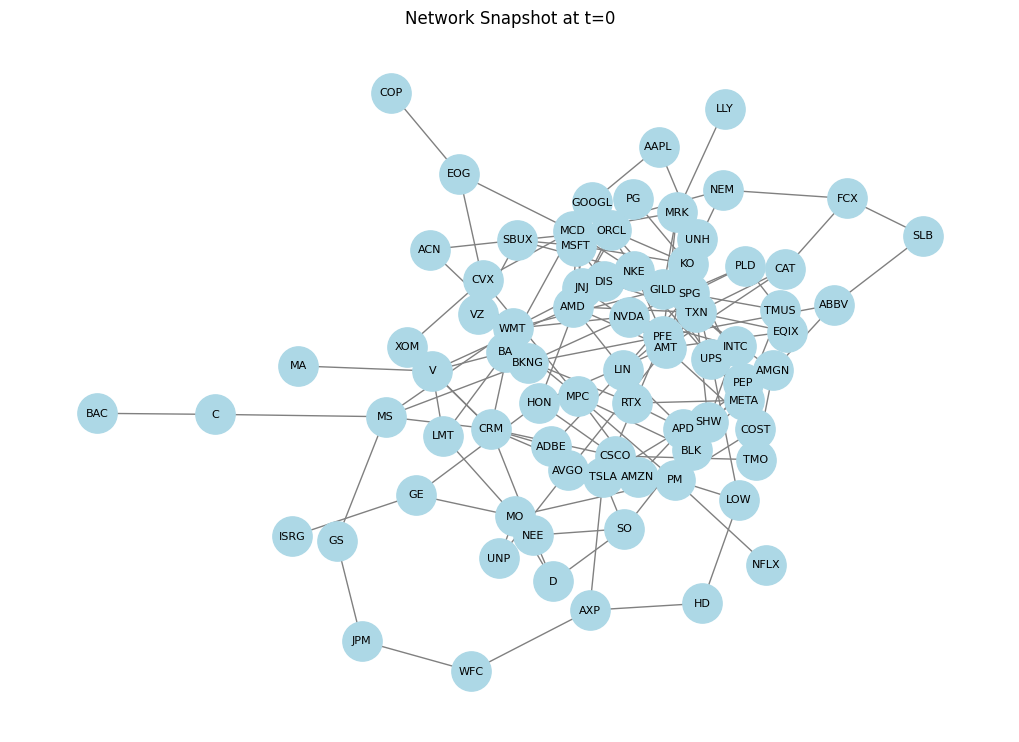

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt  # <--- 이 부분이 빠졌었습니다!
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis
import networkx as nx

def plot_network_snapshot(A_bin, tickers, t_idx):
    G = nx.from_numpy_array(A_bin)
    mapping = {i: tickers[i] for i in range(len(tickers))}
    G = nx.relabel_nodes(G, mapping)

    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=800, font_size=8)
    plt.title(f"Network Snapshot at t={t_idx}")
    plt.show()

# 첫 번째 윈도우 결과 시각화
plot_network_snapshot(A_bin_arr[0], tickers, 0)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# (필수) A_bin_arr 준비
# ============================================================
# A_bin_arr: (T,N,N) 0/1 인접행렬 (top-k 희소화 후 diag=0)
# - 가장 정확: 슬라이싱 단계에서 A_topk로부터 A_bin_arr를 같이 저장
# - 이미 준비되어 있다면 아래 if 블록은 그냥 통과됨

if "A_bin_arr" not in globals():
    raise RuntimeError(
        "A_bin_arr(0/1 타깃 인접행렬)가 없습니다.\n"
        "슬라이싱 루프에서 A_topk로부터 A_bin_arr를 같이 만들어주세요.\n"
        "예: A_bin = (A_topk > 0).astype(np.float32); diag=0"
    )

# =========================
# 1) Dataset 준비
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 입력: 정규화 adjacency (GCN 입력용)
X = torch.tensor(X_arr, dtype=torch.float32, device=device)     # (T,N,F)
A_in = torch.tensor(A_arr, dtype=torch.float32, device=device)  # (T,N,N)  <-- 입력용

# 타깃: 이진 adjacency (복원용)
A_bin = torch.tensor(A_bin_arr, dtype=torch.float32, device=device)  # (T,N,N) in {0,1}

T, N, F_in = X.shape

# 시간 누수 방지: 앞 80% train, 뒤 20% val
train_ratio = 0.8
T_train = int(T * train_ratio)

X_train, A_in_train, A_bin_train = X[:T_train], A_in[:T_train], A_bin[:T_train]
X_val,   A_in_val,   A_bin_val   = X[T_train:], A_in[T_train:], A_bin[T_train:]

# =========================
# 2) GCN + Graph AutoEncoder (self-supervised) 정의
# =========================
class MLPEmbed(nn.Module):
    def __init__(self, in_dim, out_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Linear(32, out_dim),
        )
    def forward(self, x):
        return self.net(x)  # (B,N,out_dim)

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)

    def forward(self, A_norm, X):
        return self.lin(torch.bmm(A_norm, X))  # (B,N,out_dim)

class GraphAutoEncoder(nn.Module):
    def __init__(self, x_in_dim, x_emb_dim=16, hid_dim=32, z_dim=16, dropout=0.1):
        super().__init__()
        self.x_embed = MLPEmbed(x_in_dim, x_emb_dim)

        self.gcn1 = GCNLayer(x_emb_dim, hid_dim)
        self.gcn2 = GCNLayer(hid_dim, z_dim)

        self.dropout = nn.Dropout(dropout)


        # (선택) X 복원 디코더 (유지하되 가중치 낮게 줄 것)
        self.x_decoder = nn.Sequential(
            nn.Linear(z_dim, 32),
            nn.ReLU(),
            nn.Linear(32, x_in_dim)
        )

    def encode(self, A_norm, X):
        X_emb = self.x_embed(X)                   # (B,N,16)
        H = F.relu(self.gcn1(A_norm, X_emb))      # (B,N,hid)
        H = self.dropout(H)
        Z = self.gcn2(A_norm, H)                  # (B,N,z_dim)
        # GARCH 잔차의 특성을 직접 전달하기 위해 원본 임베딩을 더해줌 (ResNet 구조)
        return Z + X_emb

    def decode_adj_logits(self, Z):
        # ✅ sigmoid 제거하고 logits 반환

        logits = torch.bmm(Z, Z.transpose(1, 2))  # (B,N,N)
        return logits

    def forward(self, A_norm, X):
        Z = self.encode(A_norm, X)
        A_logits = self.decode_adj_logits(Z)
        X_hat = self.x_decoder(Z)
        return Z, A_logits, X_hat

model = GraphAutoEncoder(x_in_dim=F_in, x_emb_dim=16, hid_dim=32, z_dim=16, dropout=0.1).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# =========================
# 3) Loss: BCE(그래프 복원) + (옵션) 피처 복원
# =========================
bce_logits = nn.BCEWithLogitsLoss(reduction="none")

def compute_global_pos_weight(A_bin_train_torch):
    """
    전역 pos_weight = #neg/#pos (diag 제외)
    """
    N = A_bin_train_torch.size(1)
    eye = torch.eye(N, device=A_bin_train_torch.device).unsqueeze(0)
    mask = (1.0 - eye)

    pos = (A_bin_train_torch * mask).sum()
    neg = ((1.0 - A_bin_train_torch) * mask).sum()
    pw = (neg / (pos + 1e-6)).clamp(min=1.0, max=50.0)
    return pw

POS_W = compute_global_pos_weight(A_bin_train)
print("global pos_weight:", float(POS_W))

def reconstruction_loss_bce(A_bin_true, A_logits, X_true, X_hat,
                            alpha_adj=1.0, alpha_x=0.001, pos_weight=1.0):
    """
    A_bin_true: (B,N,N) in {0,1}
    A_logits  : (B,N,N) logits
    """
    B, N, _ = A_bin_true.shape
    eye = torch.eye(N, device=A_bin_true.device).unsqueeze(0)  # (1,N,N)
    mask = (1.0 - eye)                                         # (1,N,N)

    # BCE with logits (elementwise)
    loss_mat = bce_logits(A_logits, A_bin_true)                 # (B,N,N)

    # pos weight
    w = 1.0 + (pos_weight - 1.0) * A_bin_true                   # (B,N,N)

    # ✅ 핵심: 배치까지 포함해서 평균
    denom = (mask.sum() * B)                                    # B*N*(N-1)
    adj_bce = (loss_mat * w * mask).sum() / denom

    x_mse = F.mse_loss(X_hat, X_true)
    return alpha_adj * adj_bce + alpha_x * x_mse, adj_bce.detach(), x_mse.detach()


# =========================
# 4) 학습 루프
# =========================
batch_size = 64
epochs = 80  # BCE는 조금 더 돌려도 좋아서 80 추천

def iterate_minibatches(Xt, A_in_t, A_bin_t, bs):
    Tt = Xt.shape[0]
    for i in range(0, Tt, bs):
        yield Xt[i:i+bs], A_in_t[i:i+bs], A_bin_t[i:i+bs]

for ep in range(1, epochs+1):
    model.train()
    tr_losses, tr_adj, tr_x = [], [], []

    for Xb, Aib, Abb in iterate_minibatches(X_train, A_in_train, A_bin_train, batch_size):
        opt.zero_grad()
        Z, A_logits, X_hat = model(Aib, Xb)

        loss, adj_bce, x_mse = reconstruction_loss_bce(
            Abb, A_logits, Xb, X_hat,
            alpha_adj=1.0,
            alpha_x=0.001,       # ✅ 피처 복원 비중 낮춤
            pos_weight=POS_W
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        tr_losses.append(loss.item())
        tr_adj.append(adj_bce.item())
        tr_x.append(x_mse.item())

    model.eval()
    with torch.no_grad():
        val_losses, val_adj, val_x = [], [], []
        for Xb, Aib, Abb in iterate_minibatches(X_val, A_in_val, A_bin_val, batch_size):
            Z, A_logits, X_hat = model(Aib, Xb)
            loss, adj_bce, x_mse = reconstruction_loss_bce(
                Abb, A_logits, Xb, X_hat,
                alpha_adj=1.0,
                alpha_x=0.001,
                pos_weight=POS_W
            )
            val_losses.append(loss.item())
            val_adj.append(adj_bce.item())
            val_x.append(x_mse.item())

    if ep % 10 == 0 or ep == 1:
        print(
            f"epoch {ep:3d}/{epochs} "
            f"train_loss={np.mean(tr_losses):.6f} (adj_bce={np.mean(tr_adj):.6f}, x_mse={np.mean(tr_x):.6f})  "
            f"val_loss={np.mean(val_losses):.6f} (adj_bce={np.mean(val_adj):.6f}, x_mse={np.mean(val_x):.6f})"
        )

# =========================
# 5) 전체 구간 임베딩 뽑기 (노드 임베딩)
# =========================
model.eval()
with torch.no_grad():
    Z_list = []
    for Xb, Aib, Abb in iterate_minibatches(X, A_in, A_bin, batch_size):
        Z = model.encode(Aib, Xb)  # (B,N,16)
        Z_list.append(Z.detach().cpu())
    H_all = torch.cat(Z_list, dim=0).numpy()   # (T,N,16)

print("H_all shape:", H_all.shape)  # (2455,16,16)


global pos_weight: 19.512008666992188
epoch   1/80 train_loss=1.321381 (adj_bce=1.320388, x_mse=0.993650)  val_loss=1.322661 (adj_bce=1.321690, x_mse=0.971446)
epoch  10/80 train_loss=1.158810 (adj_bce=1.157917, x_mse=0.893268)  val_loss=1.238448 (adj_bce=1.237577, x_mse=0.870780)
epoch  20/80 train_loss=1.128939 (adj_bce=1.128071, x_mse=0.867733)  val_loss=1.206154 (adj_bce=1.205316, x_mse=0.837893)
epoch  30/80 train_loss=1.121556 (adj_bce=1.120686, x_mse=0.870044)  val_loss=1.202267 (adj_bce=1.201424, x_mse=0.842564)
epoch  40/80 train_loss=1.109102 (adj_bce=1.108237, x_mse=0.865611)  val_loss=1.194624 (adj_bce=1.193789, x_mse=0.835043)
epoch  50/80 train_loss=1.107561 (adj_bce=1.106671, x_mse=0.890432)  val_loss=1.193024 (adj_bce=1.192157, x_mse=0.866959)
epoch  60/80 train_loss=1.099466 (adj_bce=1.098569, x_mse=0.896230)  val_loss=1.184340 (adj_bce=1.183466, x_mse=0.873693)
epoch  70/80 train_loss=1.093809 (adj_bce=1.092919, x_mse=0.890594)  val_loss=1.180736 (adj_bce=1.179870, x_

# 생각해본 test
laplacian eigenmaps니까 eigenvector뽑아서 만든 지표니 구조 복원은 당연히 잘 나올거임
top-k로 희소화 되어 있으면 엣지가 명확한 패턴을 가질 수 있어서 auc가 높을수 있음 그래서
행렬이 >0으로 이진화 했기 때문에 가중치도 잘 맞는지 살펴봐야함

# 성능 복원 후 AUC 체크

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

def eval_auc_ap_bin(A_bin, Z):
    A_bin = (A_bin > 0).astype(int)
    np.fill_diagonal(A_bin, 0)
    iu = np.triu_indices(A_bin.shape[0], k=1)
    y = A_bin[iu]

    S = Z @ Z.T
    s = 1/(1+np.exp(-S))   # sigmoid
    s = s[iu]

    auc = roc_auc_score(y, s)
    ap = average_precision_score(y, s)
    return auc, ap

aucs, aps = [], []
for t in range(A_bin_arr.shape[0]):
    auc, ap = eval_auc_ap_bin(A_bin_arr[t], H_all[t])
    aucs.append(auc); aps.append(ap)

print("mean AUC:", np.mean(aucs))
print("mean AP :", np.mean(aps))


mean AUC: 0.8218527044871444
mean AP : 0.24274118208720394


In [ ]:
# 시점별 임베딩 변화량(노드 평균)
diffs = np.linalg.norm(H_all[1:] - H_all[:-1], axis=(1,2))
print("diff mean:", diffs.mean(), "diff std:", diffs.std())


diff mean: 8.01309 diff std: 1.5247707


위는 그래프 임베딩만 진행했을 때이다. node feature들도 붙여서 16*d에서 feature 차원 F를 더해 16*(d+F)로 만들어서 임베딩 진행

# TE 생성 + Directed GAE 임베딩 코드 (Granger-TE proxy, 방향 유지 top-k per source)

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

# ============================================================
# 1) TE용 입력 생성: [수정] GARCH 잔차 재사용
# ============================================================
# pcorr 루프 내에서 z_df를 리스트로 모아두었다면 그것을 사용하고,
# 아니라면 GARCH 전처리를 거친 z_windows를 새로 만듭니다.

def make_garch_z_windows(df_returns, W=120):
    """
    [수정] EWMA 대신 GARCH(1,1) 필터를 적용하여 z_windows 생성
    """

    T_raw, N = df_returns.shape
    z_list = []
    end_idx = []

    # tqdm 추가하여 진행 상황 확인
    for end in tqdm(range(W-1, T_raw), desc="GARCH Z-Windowing"):
        wdf = df_returns.iloc[end-(W-1):end+1]
        # 앞서 정의한 get_garch_residuals 함수 호출
        z_df, _ = get_garch_residuals(wdf)
        z_list.append(z_df.values)
        end_idx.append(end)

    return np.stack(z_list, axis=0), np.array(end_idx)

# ============================================================
# 2) Granger Proxy Score: [수정] Ridge 상향 (안정성)
# ============================================================
def granger_score_lag1(Z_win, ridge=5e-2): #상향 (W=60 대응)
    W, N = Z_win.shape
    Y = Z_win[1:, :]      # (W-1, N)
    L = Z_win[:-1, :]     # (W-1, N)
    S = np.zeros((N, N), dtype=np.float32)

    for j in range(N):
        y = Y[:, j]
        xj = L[:, j]
        denom = (xj @ xj) + ridge
        a = (xj @ y) / denom
        resid0 = y - a * xj
        ssr0 = float(resid0 @ resid0) + 1e-12

        for i in range(N):
            if i == j: continue
            xi = L[:, i]
            xx11, xx22, xx12 = (xj @ xj) + ridge, (xi @ xi) + ridge, (xj @ xi)
            det = (xx11 * xx22 - xx12 * xx12)

            if det <= 1e-12: continue

            xy1, xy2 = (xj @ y), (xi @ y)
            b1 = ( xx22 * xy1 - xx12 * xy2) / det
            b2 = (-xx12 * xy1 + xx11 * xy2) / det

            resid1 = y - (b1 * xj + b2 * xi)
            ssr1 = float(resid1 @ resid1)
            imp = (ssr0 - ssr1) / ssr0
            if imp > 0: S[i, j] = imp
    return S

# ============================================================
# 3) TE 희소화: 방향 유지 top-k per source row
#    - source i 기준으로 outgoing top-k만 남김
#    - threshold로 노이즈 컷 가능
# ============================================================
def sparsify_directed_topk(S, k=3, threshold=0.0, keep_self=False):
    """
    S: (N,N) directed scores S[i,j]=i->j
    return:
      A_w   : (N,N) weighted directed adjacency (only top-k kept)
      A_bin : (N,N) 0/1 directed adjacency
    """
    N = S.shape[0]
    A = np.zeros_like(S, dtype=np.float32)

    for i in range(N):
        row = S[i].copy()
        if not keep_self:
            row[i] = 0.0
        # threshold 먼저
        row[row < threshold] = 0.0
        if k is None:
            idx = np.where(row > 0)[0]
        else:
            idx = np.argsort(row)[::-1][:k]
        for j in idx:
            if row[j] > 0:
                A[i, j] = row[j]

    A_bin = (A > 0).astype(np.float32)
    if not keep_self:
        np.fill_diagonal(A_bin, 0.0)
        np.fill_diagonal(A, 0.0)
    return A, A_bin

def normalize_incoming(A_src_to_tgt, eps=1e-8):
    """
    A_src_to_tgt[i,j]=i->j
    Directed message passing을 'incoming aggregation'으로 하려면
    A_in[tgt, src] 형태가 편함. 여기서는 그걸 만들고 row-normalize.
    return: A_in (tgt, src) row-normalized
    """
    A_in = A_src_to_tgt.T.copy()  # (tgt, src)
    row_sum = A_in.sum(axis=1, keepdims=True)
    row_sum[row_sum < eps] = 1.0
    return A_in / row_sum

# ============================================================
# 3) TE 배열 생성: [수정] 파라미터 W=60 반영
# ============================================================
def build_te_arrays_garch(df_returns, W=60, ridge=5e-2, k_te=3):
    # 1. GARCH 필터링된 z_windows 생성
    z_windows, end_idx = make_garch_z_windows(df_returns, W=W)
    T_win, _, N = z_windows.shape

    A_te_in_list, A_te_bin_list, te_scores_list = [], [], []

    for t in tqdm(range(T_win), desc="TE Matrix Building"):
        Z_win = z_windows[t]
        S = granger_score_lag1(Z_win, ridge=ridge)
        te_scores_list.append(S)

        # 희소화 및 정규화
        A_w, A_bin = sparsify_directed_topk(S, k=k_te, threshold=0.0, keep_self=False)
        A_w = np.log1p(A_w) # Weight 안정화

        A_te_bin_list.append(A_bin.astype(np.float32))
        A_in = normalize_incoming(A_w).astype(np.float32)
        A_te_in_list.append(A_in)

    return (np.stack(A_te_in_list, axis=0),
            np.stack(A_te_bin_list, axis=0),
            np.stack(te_scores_list, axis=0),
            end_idx)

    # ============================================================
# 5) Directed Graph AutoEncoder (TE 전용)
#    - X는 너가 이미 만든 X_arr 그대로 사용
#    - Encoder는 incoming & outgoing 모두 반영(성능/해석 둘 다 좋음)
#    - Decoder는 비대칭 bilinear(logits)
# ============================================================
class MLPEmbed(nn.Module):
    def __init__(self, in_dim, out_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim),
        )
    def forward(self, x):
        return self.net(x)

class DirectedRelConv(nn.Module):
    """
    H' = W0 H + Win (A_in  H) + Wout (A_out H)
    - A_in: (B,N,N) where row=target, col=source (incoming normalized)
    - A_out: (B,N,N) where row=source, col=target (outgoing normalized)  (optional)
    """
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.w0 = nn.Linear(in_dim, out_dim, bias=True)
        self.win = nn.Linear(in_dim, out_dim, bias=False)
        self.wout = nn.Linear(in_dim, out_dim, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, A_in, A_out, H):
        H0 = self.w0(H)
        Hin = self.win(torch.bmm(A_in, H))
        Hout = self.wout(torch.bmm(A_out, H))
        out = F.relu(H0 + Hin + Hout)
        return self.drop(out)

class DirectedGAE(nn.Module):
    def __init__(self, x_in_dim, x_emb_dim=16, hid_dim=64, z_dim=16, dropout=0.1):
        super().__init__()
        self.x_embed = MLPEmbed(x_in_dim, x_emb_dim)

        self.conv1 = DirectedRelConv(x_emb_dim, hid_dim, dropout=dropout)
        self.conv2 = DirectedRelConv(hid_dim, z_dim, dropout=dropout)

        # 비대칭 디코더용 projection
        self.z_src = nn.Linear(z_dim, z_dim, bias=False)
        self.z_tgt = nn.Linear(z_dim, z_dim, bias=False)

        # (옵션) X 복원(보조)
        self.x_decoder = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.ReLU(),
            nn.Linear(64, x_in_dim)
        )

    def encode(self, A_in, A_out, X):
        Xemb = self.x_embed(X)                 # (B,N,x_emb)
        H = self.conv1(A_in, A_out, Xemb)      # (B,N,hid)
        Z = self.conv2(A_in, A_out, H)         # (B,N,z)
        # residual(상태 정보 유지)
        # z_dim과 x_emb_dim이 같을 때만 더하는 게 안전. 여기선 둘 다 16으로 맞추는 걸 추천.
        if Z.shape[-1] == Xemb.shape[-1]:
            Z = Z + Xemb
        return Z

    def decode_logits(self, Z):
        Zs = self.z_src(Z)
        Zt = self.z_tgt(Z)
        return torch.bmm(Zs, Zt.transpose(1,2))  # (B,N,N) src(row)->tgt(col) logits

    def forward(self, A_in, A_out, X):
        Z = self.encode(A_in, A_out, X)
        logits = self.decode_logits(Z)
        X_hat = self.x_decoder(Z)
        return Z, logits, X_hat

# ============================================================
# 6) Loss & Train (TE는 directed이므로 diag만 마스킹, 대칭화 금지)
# ============================================================
bce_logits = nn.BCEWithLogitsLoss(reduction="none")

def compute_pos_weight(Y_bin):
    # Y_bin: (B,N,N) 0/1
    B, N, _ = Y_bin.shape
    eye = torch.eye(N, device=Y_bin.device).unsqueeze(0)
    mask = (1.0 - eye)
    pos = (Y_bin * mask).sum()
    neg = ((1.0 - Y_bin) * mask).sum()
    return (neg / (pos + 1e-6)).clamp(min=1.0, max=50.0)

def masked_bce_directed(Y_true, logits, pos_weight=1.0):
    B, N, _ = Y_true.shape
    eye = torch.eye(N, device=Y_true.device).unsqueeze(0)
    mask = (1.0 - eye)
    loss_mat = bce_logits(logits, Y_true)
    w = 1.0 + (pos_weight - 1.0) * Y_true
    denom = (mask.sum() * B)
    return (loss_mat * w * mask).sum() / denom

def train_te_gae(X_arr, A_te_in_arr, A_te_bin_arr,
                 epochs=60, batch_size=64, lr=1e-3, wd=1e-4,
                 alpha_x=0.001, train_ratio=0.8, seed=42):
    import numpy as np
    import torch
    import torch.nn.functional as F

    torch.manual_seed(seed)
    np.random.seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X = torch.tensor(X_arr, dtype=torch.float32, device=device)             # (T,N,F)
    A_in = torch.tensor(A_te_in_arr, dtype=torch.float32, device=device)    # (T,N,N) (target,row)->(source,col)

    # outgoing normalize(0/1 기반)
    A_out_np = (A_te_bin_arr / (A_te_bin_arr.sum(axis=1, keepdims=True) + 1e-8)).astype(np.float32)
    A_out = torch.tensor(A_out_np, dtype=torch.float32, device=device)      # (T,N,N) row=src outgoing normalized

    Y = torch.tensor(A_te_bin_arr, dtype=torch.float32, device=device)      # (T,N,N) src->tgt (0/1)

    T, N, F_in = X.shape
    T_tr = int(T * train_ratio)

    X_tr, Ain_tr, Aout_tr, Y_tr = X[:T_tr], A_in[:T_tr], A_out[:T_tr], Y[:T_tr]
    X_va, Ain_va, Aout_va, Y_va = X[T_tr:], A_in[T_tr:], A_out[T_tr:], Y[T_tr:]

    model = DirectedGAE(x_in_dim=F_in, x_emb_dim=16, hid_dim=64, z_dim=16, dropout=0.1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    POS_W = compute_pos_weight(Y_tr)
    print("TE pos_weight:", float(POS_W))

    def batches(*tensors):
        Tt = tensors[0].shape[0]
        for i in range(0, Tt, batch_size):
            yield [x[i:i+batch_size] for x in tensors]

    for ep in range(1, epochs+1):
        model.train()
        tr = []
        for Xb, Ainb, Aoutb, Yb in batches(X_tr, Ain_tr, Aout_tr, Y_tr):
            opt.zero_grad()
            Z, logits, X_hat = model(Ainb, Aoutb, Xb)

            loss_adj = masked_bce_directed(Yb, logits, pos_weight=POS_W)
            loss_x = F.mse_loss(X_hat, Xb)
            loss = loss_adj + alpha_x * loss_x

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr.append([loss.item(), loss_adj.item(), loss_x.item()])

        model.eval()
        with torch.no_grad():
            va = []
            for Xb, Ainb, Aoutb, Yb in batches(X_va, Ain_va, Aout_va, Y_va):
                Z, logits, X_hat = model(Ainb, Aoutb, Xb)
                loss_adj = masked_bce_directed(Yb, logits, pos_weight=POS_W)
                loss_x = F.mse_loss(X_hat, Xb)
                loss = loss_adj + alpha_x * loss_x
                va.append([loss.item(), loss_adj.item(), loss_x.item()])

        if ep % 10 == 0 or ep == 1:
            trm = np.mean(tr, axis=0)
            vam = np.mean(va, axis=0)
            print(f"ep {ep:3d}  train loss={trm[0]:.4f} (adj={trm[1]:.4f}, x={trm[2]:.4f})  "
                  f"val loss={vam[0]:.4f} (adj={vam[1]:.4f}, x={vam[2]:.4f})")

    # 임베딩 추출
    model.eval()
    with torch.no_grad():
        Z_list = []
        for Xb, Ainb, Aoutb in batches(X, A_in, A_out):
            Z = model.encode(Ainb, Aoutb, Xb)
            Z_list.append(Z.detach().cpu())
        H_te_all = torch.cat(Z_list, dim=0).numpy()   # (T,N,16)

    return H_te_all, model


# ============================================================
# 7) 실행 예시: TE 배열 생성 -> TE 임베딩 학습 -> H_te_all 생성
# ============================================================
# 너가 df를 "수익률"로 갖고 있다고 가정.
# 만약 df 컬럼명이 'r_' prefix 등으로 바뀌어 있으면 그대로 써도 됨.

W = 120
RIDGE = 1e-3

# TE sparsify 파라미터(초기 추천)
K_TE = 3          # pcorr k=4라면 TE는 2~4 추천, 일단 3
TH_TE = 0.0       # 0으로 시작하고 필요하면 0.01~0.05처럼 올리기

A_te_in_arr, A_te_bin_arr, te_scores_arr, end_idx_te = build_te_arrays_garch(df, W=W)
assert A_te_in_arr.shape[0] == X_arr.shape[0], "윈도우 개수가 불일치합니다. W값을 확인하세요!"
print("A_te_in_arr:", A_te_in_arr.shape, "A_te_bin_arr:", A_te_bin_arr.shape)

# (중요) pcorr에서 만든 X_arr와 TE에서 만든 윈도우 개수(T_win)가 동일해야 결합이 쉬움
assert A_te_in_arr.shape[0] == X_arr.shape[0], "TE windows와 X_arr windows 수가 달라요. df/W 정렬 확인!"

# TE GAE 학습 (DirectedGAE 클래스는 기존 코드 그대로 사용)
H_te_all, te_model = train_te_gae(
    X_arr=X_arr,
    A_te_in_arr=A_te_in_arr,
    A_te_bin_arr=A_te_bin_arr,
    epochs=60,
    batch_size=64,
    alpha_x=0.001
)

print(f"✅ TE 임베딩 완료: {H_te_all.shape}") # (T, N, 16)

GARCH Z-Windowing:   0%|          | 0/2394 [00:00<?, ?it/s]

TE Matrix Building:   0%|          | 0/2394 [00:00<?, ?it/s]

A_te_in_arr: (2394, 79, 79) A_te_bin_arr: (2394, 79, 79)
TE pos_weight: 25.0
ep   1  train loss=1.3248 (adj=1.3238, x=0.9931)  val loss=1.2886 (adj=1.2877, x=0.9530)
ep  10  train loss=0.8843 (adj=0.8835, x=0.7926)  val loss=0.8457 (adj=0.8449, x=0.7511)
ep  20  train loss=0.8042 (adj=0.8034, x=0.8136)  val loss=0.7656 (adj=0.7648, x=0.7747)
ep  30  train loss=0.7662 (adj=0.7654, x=0.8174)  val loss=0.7286 (adj=0.7278, x=0.7819)
ep  40  train loss=0.7366 (adj=0.7358, x=0.8220)  val loss=0.6982 (adj=0.6974, x=0.7917)
ep  50  train loss=0.7113 (adj=0.7104, x=0.8272)  val loss=0.6690 (adj=0.6682, x=0.8018)
ep  60  train loss=0.6916 (adj=0.6908, x=0.8286)  val loss=0.6457 (adj=0.6448, x=0.8083)
✅ TE 임베딩 완료: (2394, 79, 16)


# 복원성능 AUC 체크

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
import torch

def eval_directed_auc_ap_from_logits(A_bin_arr, logits_arr):
    """
    A_bin_arr: (T,N,N) 0/1 (src->tgt), diag=0
    logits_arr: (T,N,N) raw logits (src->tgt), from model.decode_logits
    """
    T = A_bin_arr.shape[0]
    aucs, aps = [], []
    for t in range(T):
        A = (A_bin_arr[t] > 0).astype(np.int32)
        np.fill_diagonal(A, 0)

        mask = ~np.eye(A.shape[0], dtype=bool)
        y = A[mask].ravel()

        s = logits_arr[t][mask].ravel()

        if y.max() == y.min():
            aucs.append(np.nan); aps.append(np.nan)
            continue

        aucs.append(roc_auc_score(y, s))
        aps.append(average_precision_score(y, s))

    return np.array(aucs, float), np.array(aps, float)

# ---- 실행: 모델로 전체 logits 뽑고 AUC/AP 평가 ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_t = torch.tensor(X_arr, dtype=torch.float32, device=device)
Ain_t = torch.tensor(A_te_in_arr, dtype=torch.float32, device=device)
Aout_t = torch.tensor((A_te_bin_arr / (A_te_bin_arr.sum(axis=1, keepdims=True) + 1e-8)).astype(np.float32),
                      dtype=torch.float32, device=device)

te_model.eval()
with torch.no_grad():
    # 전체 logits 계산 (메모리 부담되면 배치로 쪼개도 됨)
    Z = te_model.encode(Ain_t, Aout_t, X_t)
    logits = te_model.decode_logits(Z).detach().cpu().numpy()

aucs, aps = eval_directed_auc_ap_from_logits(A_te_bin_arr, logits)

print("Directed TE reconstruction (decoder-consistent)")
print("mean AUC:", np.nanmean(aucs))
print("mean AP :", np.nanmean(aps))
print("valid timesteps:", np.sum(~np.isnan(aucs)), "/", len(aucs))


Directed TE reconstruction (decoder-consistent)
mean AUC: 0.9257469788519975
mean AP : 0.31933961029936125
valid timesteps: 2394 / 2394


# 시점 변화 diff

In [ ]:
import numpy as np

def embedding_dynamics(H):
    """
    H: (T,N,d)
    return: diffs (T-1,), mean, std
    """
    diffs = np.linalg.norm(H[1:] - H[:-1], axis=(1,2))
    return diffs, diffs.mean(), diffs.std()

# ---- 실행 ----
diffs, dm, ds = embedding_dynamics(H_te_all)
print("TE embedding dynamics")
print("diff mean:", dm)
print("diff std :", ds)
print("min/max  :", diffs.min(), diffs.max())


TE embedding dynamics
diff mean: 37.430332
diff std : 6.9661994
min/max  : 19.189524 79.116486


# 희소화 민감도

In [ ]:
import numpy as np

def edge_flip_ratio(A_bin_arr):
    """
    A_bin_arr: (T,N,N) 0/1 directed
    return: flip ratios per timestep (T-1,), mean, std
    """
    flips = []
    for t in range(1, A_bin_arr.shape[0]):
        flips.append(np.mean(A_bin_arr[t] != A_bin_arr[t-1]))
    flips = np.array(flips, dtype=np.float64)
    return flips, flips.mean(), flips.std()

# ---- 실행(현재 A_te_bin_arr에 대해) ----
flips, fm, fs = edge_flip_ratio(A_te_bin_arr)
print("TE edge flip ratio (current k/threshold setting)")
print("mean:", fm)
print("std :", fs)
print("min/max:", flips.min(), flips.max())


TE edge flip ratio (current k/threshold setting)
mean: 0.010496753436105535
std : 0.003308500274613041
min/max: 0.0025636917160711424 0.0355712225604871


In [ ]:
import numpy as np

def summarize_embeddings(H, name="H"):
    """
    H: (T,N,d)
    """
    T, N, d = H.shape
    print(f"[{name}] shape: {H.shape}")
    print(f"[{name}] mean/std: {H.mean():.4f} / {H.std():.4f}")
    print(f"[{name}] min/max: {H.min():.4f} / {H.max():.4f}")

# ---- 실행 ----
# pcorr 임베딩 변수가 H_all 또는 H_pc_all로 있을 수 있으니 맞춰서 사용
H_pc_all = H_all  # 너 환경에 맞게 바꿔줘: H_all or H_pc_all

assert H_pc_all.shape[0] == H_te_all.shape[0], "pcorr/TE time length mismatch"
assert H_pc_all.shape[1] == H_te_all.shape[1], "pcorr/TE N mismatch"

H_concat = np.concatenate([H_pc_all, H_te_all], axis=-1)  # (T,N,d_pc+d_te)

summarize_embeddings(H_pc_all, "H_pc")
summarize_embeddings(H_te_all, "H_te")
summarize_embeddings(H_concat, "H_concat")


[H_pc] shape: (2394, 79, 16)
[H_pc] mean/std: 0.0076 / 0.3207
[H_pc] min/max: -2.8520 / 2.2981
[H_te] shape: (2394, 79, 16)
[H_te] mean/std: 1.0077 / 1.7463
[H_te] min/max: -5.9587 / 50.3623
[H_concat] shape: (2394, 79, 32)
[H_concat] mean/std: 0.5077 / 1.3514
[H_concat] min/max: -5.9587 / 50.3623


In [ ]:
import numpy as np

# H_concat이 생성된 직후 실행
save_path = "/content/drive/MyDrive/bitimin_last/H_concat_final.npy"
np.save(save_path, H_concat)
print(f"✅ H_concat 저장 완료: {H_concat.shape}")

# 날짜 인덱스도 함께 저장해두면 나중에 동기화할 때 매우 편합니다!
np.save("/content/drive/MyDrive/bitimin_last/end_dates.npy", end_dates)

✅ H_concat 저장 완료: (2394, 79, 32)


In [ ]:
import numpy as np

# 저장된 파일 로드
H_concat = np.load("/content/drive/MyDrive/bitimin_last/H_concat_final.npy")
end_dates = np.load("/content/drive/MyDrive/bitimin_last/end_dates.npy", allow_pickle=True)

print(f"🚀 데이터 로드 완료! H_concat: {H_concat.shape}, 기간: {len(end_dates)}일")
# 이제 바로 '인덱스 동기화 및 VIX 로드' 셀부터 실행하시면 됩니다.

🚀 데이터 로드 완료! H_concat: (2394, 79, 32), 기간: 2394일


# y label

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import torch
import os
from torch.utils.data import TensorDataset, DataLoader, Subset
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. 날짜 기준점 설정 및 VIX/GLD 로드
# ============================================================
end_dates_idx = pd.to_datetime(pd.Index(end_dates)).tz_localize(None)

start_date = (end_dates_idx.min() - pd.Timedelta(days=10)).strftime("%Y-%m-%d")
end_date   = (end_dates_idx.max() + pd.Timedelta(days=10)).strftime("%Y-%m-%d")

# VIX 다운로드
vix_df = yf.download("^VIX", start=start_date, end=end_date, interval="1d", auto_adjust=False, progress=False)
vix_raw_series = vix_df["Close"].copy().tz_localize(None)

### [추가] GLD(금) 데이터 다운로드 ###
gld_df = yf.download("GLD", start=start_date, end=end_date, interval="1d", auto_adjust=False, progress=False)
gld_raw_series = gld_df["Close"].copy().tz_localize(None)

# [동기화 핵심] 주가, VIX, 그리고 GLD 인덱스의 공통 교집합만 추출
common_idx = end_dates_idx.intersection(vix_raw_series.index).intersection(gld_raw_series.index)
synced_idx = sorted(common_idx)

common_idx = end_dates_idx.intersection(vix_raw_series.index) \
                          .intersection(gld_raw_series.index) \
                          .intersection(df.index)

synced_idx = sorted(common_idx)

print(f"✅ [단계 1] 완벽 동기화 완료: {len(synced_idx)}일 (임베딩 & VIX & GLD & 수익률 모두 존재)")

# ============================================================
# 2. 동기화된 인덱스 기반 피처 필터링 및 계산
# ============================================================
# (1) VIX 필터링
vix_values = vix_raw_series.reindex(synced_idx).values.reshape(-1, 1) # 교집합이므로 ffill 불필요
vix_log_ret = np.log(vix_values[1:] / (vix_values[:-1] + 1e-9))
vix_log_ret = np.insert(vix_log_ret, 0, 0).reshape(-1, 1)

# (1-2) GLD 필터링
gld_values = gld_raw_series.reindex(synced_idx).values.reshape(-1, 1)
gld_log_ret = np.log(gld_values[1:] / (gld_values[:-1] + 1e-9))
gld_log_ret = np.insert(gld_log_ret, 0, 0).reshape(-1, 1)

# (2) ETF 수익률(df) 필터링
adj_close_cols = [c for c in df.columns if "Adj Close" in c or "r_" in c]
if not adj_close_cols: adj_close_cols = df.columns.tolist()

# [사용자님 의도 반영] 완벽한 교집합이므로 reindex만으로도 NaN이 발생하지 않습니다.
etf_returns = df[adj_close_cols].reindex(synced_idx)

# 시장 평균 및 동조화 계산
market_avg_ret = etf_returns.mean(axis=1).values.reshape(-1, 1)
sync_index = ((etf_returns < 0).sum(axis=1).values / (len(adj_close_cols) + 1e-9)).reshape(-1, 1)

# (3) 네트워크 임베딩 필터링
valid_mask = end_dates_idx.isin(synced_idx)
H_market_valid = np.concatenate([H_concat.mean(axis=1), H_concat.max(axis=1)], axis=-1)[valid_mask]

# ============================================================
# 3. 최종 스케일링 및 X 결합
# ============================================================
# 모든 입력값의 행 개수가 len(synced_idx)로 동일하므로 안전하게 결합됩니다.
H_final_input = np.concatenate([
    StandardScaler().fit_transform(H_market_valid),
    StandardScaler().fit_transform(vix_values),
    StandardScaler().fit_transform(vix_log_ret),
    StandardScaler().fit_transform(market_avg_ret),
    StandardScaler().fit_transform(sync_index),
    StandardScaler().fit_transform(gld_values),
    StandardScaler().fit_transform(gld_log_ret)
], axis=-1)

print("-" * 30)
print(f"🚀 [결과] H_final_input 생성 완료! Shape: {H_final_input.shape}")
print(f"🚫 [최종] 결측치(NaN) 합계: {np.isnan(H_final_input).sum()}개")

✅ [단계 1] 완벽 동기화 완료: 2394일 (임베딩 & VIX & GLD & 수익률 모두 존재)
------------------------------
🚀 [결과] H_final_input 생성 완료! Shape: (2394, 70)
🚫 [최종] 결측치(NaN) 합계: 0개


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader, Subset
import pandas as pd
import numpy as np

scaler_vix = StandardScaler()
vix_scaled = scaler_vix.fit_transform(vix_values)
# ============================================================
# [수정] 2단계: Score 기반 시스템 리스크 정의 (동기화된 변수 사용)
# ============================================================
def create_forward_looking_sequences(features, targets_scaled, m_ret, s_idx, v_raw, seq_len=20, p=5, window=5):
    X, y_reg, y_cls = [], [], []

    # 1. 종합 위험 점수 산출 (이미 동기화된 m_ret, s_idx 사용)
    # pd.Series로 변환하여 rank 계산
    crash_score = pd.Series(m_ret.flatten()).rank(pct=True, ascending=True)
    sync_score = pd.Series(s_idx.flatten()).rank(pct=True, ascending=False)

    # VIX 변화율 (이미 동기화된 v_raw 기반)
    vix_change = np.insert(v_raw[1:] / (v_raw[:-1] + 1e-9), 0, 1.0)
    panic_score = pd.Series(vix_change.flatten()).rank(pct=True, ascending=False)

    # 세 점수의 평균으로 종합 리스크 순위 산출 (NaN은 중립값 0.5로 채움)
    total_risk_rank = ((crash_score + sync_score + panic_score) / 3).fillna(0.5).values

    # 하위 p%를 위기 임계치로 설정
    risk_threshold = np.nanpercentile(total_risk_rank, p)

    # 2. 시퀀스 생성
    for i in range(len(features) - seq_len - window):
        idx = i + seq_len

        # [X] 과거 20일 데이터 (t-20 ~ t-1)
        X.append(features[i : idx])

        # [y_reg] 오늘의 타겟 (VIX 등 회귀용)
        y_reg.append(targets_scaled[idx])

        # [y_cls] 조기 경보 라벨링: t시점부터 t+window 이내에 위기가 발생하는가?
        future_risks = total_risk_rank[idx : idx + window]
        if np.any(future_risks <= risk_threshold):
            y_cls.append(1)
        else:
            y_cls.append(0)

    return np.array(X), np.array(y_reg), np.array(y_cls)

# [적용] 앞 셀에서 만든 변수들을 그대로 주입
# vix_values는 스케일링 전 원본, vix_scaled는 스케일링 후를 의미합니다.
X_np, y_reg_np, y_cls_np = create_forward_looking_sequences(
    H_final_input,
    vix_scaled,
    market_avg_ret, # 앞 셀의 진단 결과(유효성 확인된 값)
    sync_index,     # 앞 셀의 진단 결과
    vix_values.flatten(), # 원본 VIX
    seq_len=20, p=5, window=3 # p=5, window=3 전략 적용
)

# ============================================================
# 3단계: Tensor 변환 및 데이터 분할 (이후 동일)
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_ts = torch.tensor(X_np, dtype=torch.float32)
y_reg_ts = torch.tensor(y_reg_np, dtype=torch.float32)
y_cls_ts = torch.tensor(y_cls_np, dtype=torch.float32).view(-1, 1)

split = int(len(X_ts) * 0.8)
full_dataset = TensorDataset(X_ts, y_reg_ts, y_cls_ts)

train_indices = np.arange(split)
val_indices = np.arange(split, len(X_ts))

train_loader = DataLoader(Subset(full_dataset, train_indices), batch_size=32, shuffle=True)
val_loader = DataLoader(Subset(full_dataset, val_indices), batch_size=32, shuffle=False)

print("-" * 30)
print(f"✅ 동기화 데이터 기반 학습 준비 완료!")
print(f"📊 최종 위기 일수 (Label 1): {int(sum(y_cls_np))}일 / 전체 {len(y_cls_np)}일")

------------------------------
✅ 동기화 데이터 기반 학습 준비 완료!
📊 최종 위기 일수 (Label 1): 326일 / 전체 2371일


In [ ]:
import torch
import torch.nn as nn

import math
import torch
import torch.nn as nn

class VixTransformer(nn.Module):
    def __init__(self, input_dim=34, model_dim=64, n_heads=8, n_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, model_dim)

        # --- [수정] Sinusoidal Positional Encoding 생성 로직 ---
        max_len = 20
        pe = torch.zeros(max_len, model_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, model_dim, 2).float() * (-math.log(10000.0) / model_dim))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # (1, 20, model_dim)

        # register_buffer는 이 값이 가중치처럼 업데이트되지 않도록 고정하면서,
        # model.to(device) 호출 시 함께 이동하게 해줍니다.
        self.register_buffer('pos_encoding', pe)
        # --------------------------------------------------

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=n_heads, dim_feedforward=model_dim*4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=n_layers)

        self.reg_head = nn.Sequential(
            nn.Linear(model_dim, 32), nn.ReLU(), nn.Linear(32, 1)
        )
        self.cls_head = nn.Sequential(
            nn.Linear(model_dim, 32), nn.ReLU(), nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (Batch, Seq_len, Input_dim)

        # [수정] 랜덤 파라미터 대신 등록된 고정 인코딩을 더함
        x = self.embedding(x) + self.pos_encoding[:, :x.size(1), :]

        x = self.transformer(x)
        last_h = x[:, -1, :]

        reg_out = self.reg_head(last_h)
        cls_out = self.cls_head(last_h)

        return reg_out, cls_out

# 모델 생성 시 입력 차원을 명시적으로 확인 (34개 피처)
# 최적 파라미터 적용
model = VixTransformer(
    input_dim=X_ts.shape[-1],
    model_dim=128,
    n_heads=4,
    dropout=0.319
).to(device)


In [ ]:

import copy
import torch.nn.functional as F


# Focal Loss 정의 (Gamma: 2.01 반영)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # targets: 0/1 float
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        pt = targets * p + (1 - targets) * (1 - p)  # 정답 클래스 확률
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_t * (1 - pt).pow(self.gamma) * bce
        return loss.mean() if self.reduction == "mean" else loss.sum()


def log_cosh_loss(y_pred, y_true):
    return torch.mean(torch.log(torch.cosh(y_pred - y_true + 1e-12)))

# 학습 설정 (Alpha_cls: 3.40 반영)
best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float('inf')
alpha_cls = 4.1218

criterion_reg = nn.MSELoss()
criterion_cls = FocalLoss(alpha=0.25, gamma=4.7744).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"🚀 최적 파라미터 기반 최종 학습 시작...")

for ep in range(1, 200): # 충분한 학습을 위해 에폭 상향
    model.train()
    train_loss = 0
    for xb, yrb, ycb in train_loader:
        xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
        optimizer.zero_grad()
        reg_p, cls_p = model(xb)
        loss = log_cosh_loss(reg_p, yrb) + alpha_cls * criterion_cls(cls_p, ycb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss, reg_mse, correct = 0, 0, 0
    with torch.no_grad():
        for xb, yrb, ycb in val_loader:
            xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
            reg_p, cls_p = model(xb)
            # 1. MSE 대신 log_cosh_loss를 사용합니다.
            reg_loss = log_cosh_loss(reg_p, yrb)

            # 2. 전체 검증 손실(v_loss) 계산
            v_loss = reg_loss + alpha_cls * criterion_cls(cls_p, ycb)

            # 3. 지표 누적
            val_loss += v_loss.item()
            reg_mse += reg_loss.item() # 여기도 log_cosh 값으로 기록됩니다.

            # 4. 분류 정확도 계산 (기존 유지)
            correct += ((torch.sigmoid(cls_p) > 0.4402).float() == ycb).sum().item()
    avg_val_loss = val_loss / len(val_loader)
    avg_acc = correct / len(val_ds)

    scheduler.step(avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if ep % 10 == 0 or ep == 1:
        print(f"Epoch {ep:3d} | Val Loss: {avg_val_loss:.4f} | Acc: {avg_acc:.4f} | P: {counter}")
    if counter >= 15: break

model.load_state_dict(best_model_wts)
print("✅ 최종 모델 복원 완료.")

🚀 최적 파라미터 기반 최종 학습 시작...
Epoch   1 | Val Loss: 0.1529 | Acc: 0.6842 | P: 0
Epoch  10 | Val Loss: 0.0967 | Acc: 0.6358 | P: 0
Epoch  20 | Val Loss: 0.0946 | Acc: 0.5895 | P: 0
Epoch  30 | Val Loss: 0.0960 | Acc: 0.5979 | P: 2
Epoch  40 | Val Loss: 0.0969 | Acc: 0.5895 | P: 9
✅ 최종 모델 복원 완료.


# optuna를 위한 vell

In [ ]:
pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 31.2 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn

import math
import torch
import torch.nn as nn

class VixTransformer(nn.Module):
    def __init__(self, input_dim=34, model_dim=64, n_heads=8, n_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, model_dim)

        # --- [수정] Sinusoidal Positional Encoding 생성 로직 ---
        max_len = 20
        pe = torch.zeros(max_len, model_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, model_dim, 2).float() * (-math.log(10000.0) / model_dim))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # (1, 20, model_dim)

        # register_buffer는 이 값이 가중치처럼 업데이트되지 않도록 고정하면서,
        # model.to(device) 호출 시 함께 이동하게 해줍니다.
        self.register_buffer('pos_encoding', pe)
        # --------------------------------------------------

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=n_heads, dim_feedforward=model_dim*4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=n_layers)

        self.reg_head = nn.Sequential(
            nn.Linear(model_dim, 32), nn.ReLU(), nn.Linear(32, 1)
        )
        self.cls_head = nn.Sequential(
            nn.Linear(model_dim, 32), nn.ReLU(), nn.Linear(32, 1)
        )

    def forward(self, x):
        recent_signal = self.embedding(x[:, -1, :])

        x = self.embedding(x) + self.pos_encoding[:, :x.size(1), :]
        x = self.transformer(x)
        last_h = x[:, -1, :]

        # [솔루션] Transformer 결과에 최근 신호를 직접 더함 (잔차 연결)
        combined_h = last_h + recent_signal

        reg_out = self.reg_head(combined_h)
        cls_out = self.cls_head(combined_h)
        return reg_out, cls_out

# 모델 생성 시 입력 차원을 명시적으로 확인 (34개 피처)
# 최적 파라미터 적용
model = VixTransformer(
    input_dim=X_ts.shape[-1],
    model_dim=128,
    n_heads=4,
    dropout=0.319
).to(device)


In [ ]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna
import numpy as np
from sklearn.metrics import f1_score, balanced_accuracy_score, precision_score
# 가중치 초기화 함수
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

# 1. Focal Loss (alpha를 0.8로 상향하여 위기 탐지 강화)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0, reduction="sum"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        pt = targets * p + (1 - targets) * (1 - p)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_t * (1 - pt).pow(self.gamma) * bce
        return loss.mean() if self.reduction == "mean" else loss.sum()

def log_cosh_loss(y_pred, y_true):
    return torch.mean(torch.log(torch.cosh(y_pred - y_true + 1e-12)))

# 2. Optuna Objective 함수 정의
def objective(trial):
    # lr = trial.suggest_float("lr", 1e-5, 8e-5, log=True)
    # gamma = trial.suggest_float("gamma", 1.5, 3.0)
    # trial_alpha_cls = trial.suggest_float("alpha_cls", 5.0, 15.0)

    # local_model = VixTransformer(
    #     input_dim=X_ts.shape[-1], model_dim=128, n_heads=4, dropout=0.35
    # ).to(device)
    # lr은 현재 1.8e-5 근처가 좋으니 범위를 좁혀서 더 세밀하게 탐색
    lr = trial.suggest_float("lr", 1e-5, 5e-5, log=True)
    # gamma 상한선을 높여서 어려운 위기 상황에 더 집중하게 함
    gamma = trial.suggest_float("gamma", 2.0, 4.0)
    # alpha_cls는 현재 6.0 근처가 좋으니 이 근방을 탐색
    trial_alpha_cls = trial.suggest_float("alpha_cls", 5.0, 10.0)

    # 모델의 두뇌(Dimension)를 조금 더 키워봅니다.
    local_model = VixTransformer(
        input_dim=X_ts.shape[-1], model_dim=128, n_heads=8, dropout=0.3
    ).to(device)
    local_model.apply(init_weights)

    # Optuna 내에서도 강화된 alpha 적용
    criterion_cls = FocalLoss(alpha=0.8, gamma=gamma).to(device)
    optimizer = torch.optim.Adam(local_model.parameters(), lr=lr, weight_decay=1e-4)

    best_score = 0  # 변수명 통일 (UnboundLocalError 방지)

    for ep in range(1, 41):
        local_model.train()
        for xb, yrb, ycb in train_loader:
            xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
            optimizer.zero_grad()
            reg_p, cls_p = local_model(xb)
            loss = log_cosh_loss(reg_p, yrb) + trial_alpha_cls * criterion_cls(cls_p, ycb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(local_model.parameters(), 1.0)
            optimizer.step()

        local_model.eval()
        val_probs, val_targets = [], []
        with torch.no_grad():
            for xb, _, ycb in val_loader:
                _, cls_p = local_model(xb.to(device))
                val_probs.extend(torch.sigmoid(cls_p).cpu().numpy())
                val_targets.extend(ycb.numpy())

        val_probs = np.array(val_probs).flatten()
        val_targets = np.array(val_targets).flatten()

        # 0.1~0.5 범위에서 최적의 임계값 탐색 (Recall 확보 목적)
        thresholds = np.linspace(0.1, 0.5, 41)
        current_scores = []
        for t in thresholds:
            preds = (val_probs > t).astype(int)
            f1 = f1_score(val_targets, preds, zero_division=0)
            # 정밀도 계산
            precision = precision_score(val_targets, preds, zero_division=0)
            # Balanced Accuracy (재현율)
            b_acc = balanced_accuracy_score(val_targets, preds)

            # [변경] Precision 비중을 추가하여 오보를 내면 점수가 깎이도록 유도
            # Score = (F1 * 0.3) + (Precision * 0.4) + (B.Acc * 0.3)
            current_scores.append(f1 * 0.3 + precision * 0.4 + b_acc * 0.3)

        max_score = max(current_scores)
        if max_score > best_score:
            best_score = max_score

    return best_score

# 3. 최적화 실행
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("-" * 30)
print("Best Parameters:", study.best_params)

# 4. 최종 학습 (Best Params 반영)
# 4. 최종 학습 (Best Params 반영 + 정밀도 최적화 튜닝)
best = study.best_params
model = VixTransformer(input_dim=X_ts.shape[-1], model_dim=128, n_heads=4, dropout=0.35).to(device)
model.apply(init_weights)

# [수정] alpha를 0.7 정도로 낮춰 오보에 대한 벌칙 강화
criterion_cls = FocalLoss(alpha=0.7, gamma=best['gamma']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=best['lr'], weight_decay=1e-4)

print(f"🚀 [정밀도 강화 모드] 최종 학습 시작...")

best_model_wts = copy.deepcopy(model.state_dict())
best_val_score = 0
final_best_t = 0.4 # 임계값을 조금 더 엄격하게 시작
counter = 0

for ep in range(1, 151): # 조금 더 길게 학습하여 안정화
    model.train()
    for xb, yrb, ycb in train_loader:
        xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
        optimizer.zero_grad()
        reg_p, cls_p = model(xb)

        # [수정] 가중치를 20.0 -> 7.0으로 낮춤 (회귀와 분류의 균형)
        loss = log_cosh_loss(reg_p, yrb) + 7.0 * criterion_cls(cls_p, ycb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    model.eval()
    val_probs, val_targets = [], []
    with torch.no_grad():
        for xb, _, ycb in val_loader:
            _, cls_p = model(xb.to(device))
            val_probs.extend(torch.sigmoid(cls_p).cpu().numpy())
            val_targets.extend(ycb.numpy())

    val_probs = np.array(val_probs).flatten()
    val_targets = np.array(val_targets).flatten()

    # [수정] 저장 기준을 F1-Score로 변경 (정밀도와 재현율의 조화)
    thresholds = np.linspace(0.2, 0.6, 41)
    scores = [f1_score(val_targets, (val_probs > t).astype(int), zero_division=0) for t in thresholds]

    current_max_f1 = max(scores)
    current_t = thresholds[np.argmax(scores)]

    # [수정] 단순히 위기를 맞추는 게 아니라 F1이 개선될 때만 저장
    if current_max_f1 > best_val_score:
        best_val_score = current_max_f1
        final_best_t = current_t
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if ep % 10 == 0 or ep == 1:
        print(f"Epoch {ep:3d} | Best F1: {best_val_score:.4f} | T: {final_best_t:.2f} | P: {counter}")

    if counter >= 30: break

model.load_state_dict(best_model_wts)
print(f"✅ 정밀도 보정 모델 복원 완료. (Best F1: {best_val_score:.4f} at T: {final_best_t:.4f})")
print_final_performance_report(model, val_loader, device, threshold=final_best_t)

[I 2026-02-15 23:52:38,530] A new study created in memory with name: no-name-3688a0e3-ea84-40a8-89ce-569a41c99750
[W 2026-02-15 23:52:44,541] Trial 0 failed with parameters: {'lr': 4.195541952846016e-05, 'gamma': 2.639133376363279, 'alpha_cls': 6.293319127157822} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-2414489583.py", line 67, in objective
    reg_p, cls_p = local_model(xb)
                   ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1775, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1786, in _call_impl
    return forward_call(*args, **kwargs)
    

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
import numpy as np
import torch

def print_final_performance_report(model, val_loader, device, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for xb, _, ycb in val_loader:
            xb = xb.to(device)
            _, cls_p = model(xb)
            prob = torch.sigmoid(cls_p).cpu().numpy()
            all_probs.extend(prob)
            all_labels.extend(ycb.numpy())

    all_probs = np.array(all_probs).flatten()
    all_labels = np.array(all_labels).flatten()
    preds = (all_probs > threshold).astype(float)

    # --- [추가 지표 계산] ---
    auroc = roc_auc_score(all_labels, all_probs)
    auprc = average_precision_score(all_labels, all_probs) # 불균형 데이터에서 핵심!

    print("👑 [The Final Performance Report]")
    print(f"📊 AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}") # 모델의 전반적인 변별력 확인
    print("-" * 50)

    # digits=4로 설정하여 미세한 변화 감지
    report = classification_report(all_labels, preds, target_names=['Normal (0)', 'Crisis (1)'], digits=4)
    print(report)

    print("Confusion Matrix:")
    cm = confusion_matrix(all_labels, preds)
    # 가독성을 높인 출력
    print(f"               Predicted")
    print(f"               0         1")
    print(f"Actual 0:  [{cm[0,0]:5d} {cm[0,1]:5d}]  (정상인데 위기로 오보)")
    print(f"Actual 1:  [{cm[1,0]:5d} {cm[1,1]:5d}]  (위기인데 놓침/적중)")

    # 위기 탐지율(Recall) 강조 출력
    recall_1 = cm[1,1] / (cm[1,0] + cm[1,1] + 1e-9)
    print(f"\n📢 위기 탐지 성공률(Recall): {recall_1*100:.2f}%")


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch

def print_final_performance_report(model, val_loader, device, threshold=0.2167):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb, yrb, ycb in val_loader:
            xb = xb.to(device)
            _, cls_p = model(xb)
            prob = torch.sigmoid(cls_p).cpu().numpy()
            all_probs.extend(prob)
            all_labels.extend(ycb.numpy())

    all_probs = np.array(all_probs).flatten()
    all_labels = np.array(all_labels).flatten()

    # 지정된 임계치로 예측값 생성
    preds = (all_probs > threshold).astype(float)

    # 1. 상단 타이틀 및 텍스트 리포트 출력 (이미지와 동일 포맷)
    print("👑 [The Final Performance Report]")
    # digits=2로 설정하여 소수점 두 자리까지 출력
    report = classification_report(all_labels, preds, target_names=['0.0', '1.0'], digits=2)
    print(report)

    # 2. Confusion Matrix 출력
    print("Confusion Matrix:")
    cm = confusion_matrix(all_labels, preds)
    # 이미지와 동일하게 대괄호([]) 형식을 유지하기 위해 직접 출력
    print(f" [[{cm[0,0]:3d} {cm[0,1]:3d}]")
    print(f"  [{cm[1,0]:3d} {cm[1,1]:3d}]]")

# 실행 (threshold는 상황에 맞춰 0.38 등으로 변경 가능)
print_final_performance_report(model, val_loader, device, threshold=0.4402)

👑 [The Final Performance Report]
              precision    recall  f1-score   support

         0.0       1.00      0.37      0.54       475
         1.0       0.00      0.00      0.00         0

    accuracy                           0.37       475
   macro avg       0.50      0.19      0.27       475
weighted avg       1.00      0.37      0.54       475

Confusion Matrix:
 [[176 299]
  [  0   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
model.eval()
probs, ys = [], []
with torch.no_grad():
    for xb, yrb, ycb in val_loader:
        xb = xb.to(device)
        logits = model(xb)[1]
        probs.append(torch.sigmoid(logits).cpu().numpy().ravel())
        ys.append(ycb.cpu().numpy().ravel())
p = np.concatenate(probs); y = np.concatenate(ys)

print("prob min/mean/max:", p.min(), p.mean(), p.max())
print("true pos rate:", y.mean())
print("pred pos rate @0.5:", (p>0.5).mean())
from sklearn.metrics import f1_score
best_t, best_f1 = 0.5, -1
for t in np.linspace(0.05, 0.95, 181):
    f1 = f1_score(y, (p>t).astype(int))
    if f1 > best_f1:
        best_f1, best_t = f1, t
print("best_t:", best_t, "best_f1:", best_f1)
print("pred pos rate @best_t:", (p>best_t).mean())


prob min/mean/max: 0.35047817 0.4050486 0.45749435
true pos rate: 0.23368421
pred pos rate @0.5: 0.0
best_t: 0.36499999999999994 best_f1: 0.38341968911917096
pred pos rate @best_t: 0.9852631578947368


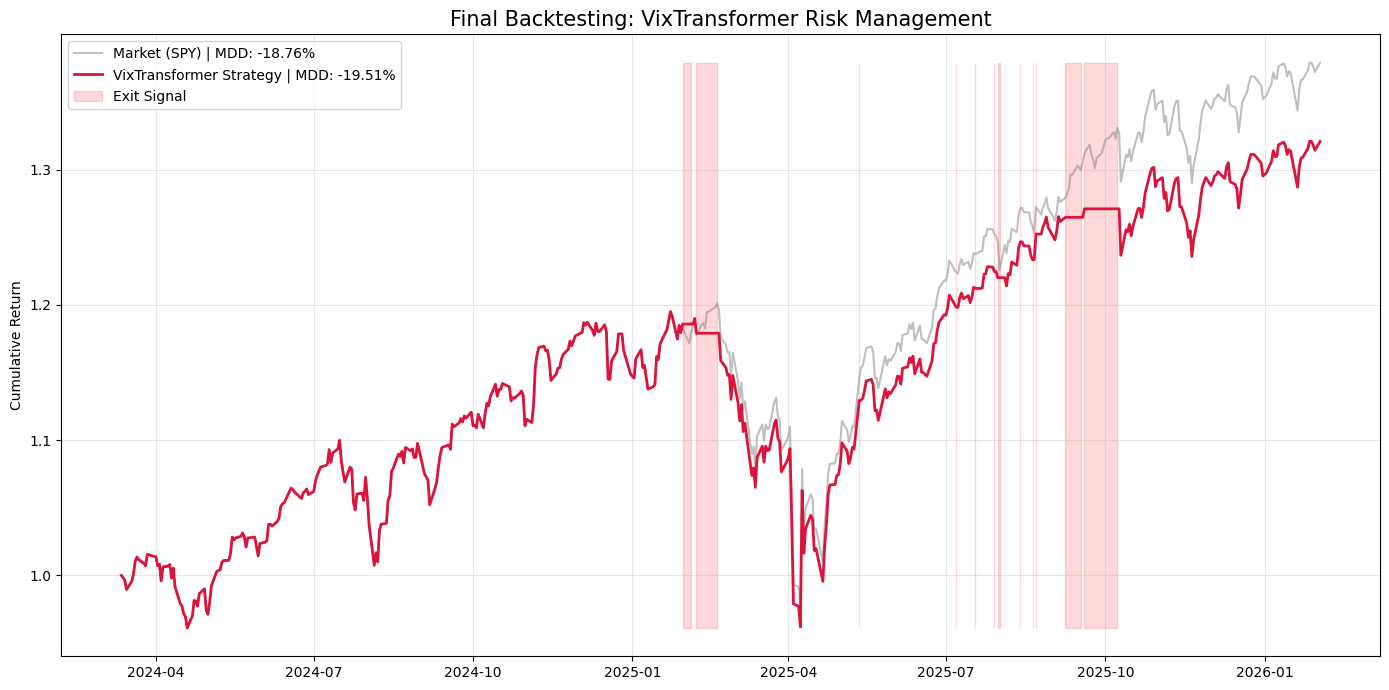

📊 [최종 성적표]
누적 수익률: 시장 1.3789 vs 전략 1.3208
최대 낙폭(MDD): 시장 -18.76% vs 전략 -19.51%


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 날짜 및 신호 정렬 (1차원으로 통일)
val_dates = pd.to_datetime(end_dates_idx[-len(test_probs):])
signals = np.array(test_probs).flatten() # 1차원 변환
final_threshold = 0.4402
binary_signals = (signals > final_threshold).astype(int)

# 2. SPY 데이터 다운로드 및 수익률 계산
spy_df = yf.download("SPY", start=val_dates.min(), end=val_dates.max() + pd.Timedelta(days=5), progress=False, auto_adjust=True)
spy_close = spy_df['Close'].reindex(val_dates).ffill()
spy_returns_val = np.log(spy_close / spy_close.shift(1)).fillna(0).values.flatten() # 1차원 변환

# 3. 전략 수익률 계산 (Look-ahead bias 방지를 위해 signal 1일 shift)
# 오늘 밤 신호를 보고 '내일' 수익률을 조절함
strategy_returns = spy_returns_val * (1 - np.roll(binary_signals, 1))
strategy_returns[0] = 0 # 첫 날 보정

# 4. 누적 수익률 및 MDD 계산
cum_market = np.exp(np.cumsum(spy_returns_val))
cum_strategy = np.exp(np.cumsum(strategy_returns))

def get_mdd(cum_returns):
    peak = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - peak) / peak
    return drawdown.min()

mdd_m = get_mdd(cum_market)
mdd_s = get_mdd(cum_strategy)

# 5. 최종 시각화 (IndexError 방지 처리)
plt.figure(figsize=(14, 7))
plt.plot(val_dates, cum_market, label=f'Market (SPY) | MDD: {mdd_m:.2%}', color='gray', alpha=0.5)
plt.plot(val_dates, cum_strategy, label=f'VixTransformer Strategy | MDD: {mdd_s:.2%}', color='crimson', linewidth=2)

# 위기 신호 발생 구간 표시 (where 조건에 flatten된 binary_signals 사용)
plt.fill_between(val_dates, cum_market.min(), cum_market.max(),
                 where=(binary_signals == 1), color='red', alpha=0.15, label='Exit Signal')

plt.title("Final Backtesting: VixTransformer Risk Management", fontsize=15)
plt.ylabel("Cumulative Return")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📊 [최종 성적표]")
print(f"누적 수익률: 시장 {cum_market[-1]:.4f} vs 전략 {cum_strategy[-1]:.4f}")
print(f"최대 낙폭(MDD): 시장 {mdd_m:.2%} vs 전략 {mdd_s:.2%}")

In [ ]:
pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.0 MB/s eta 0:00:00


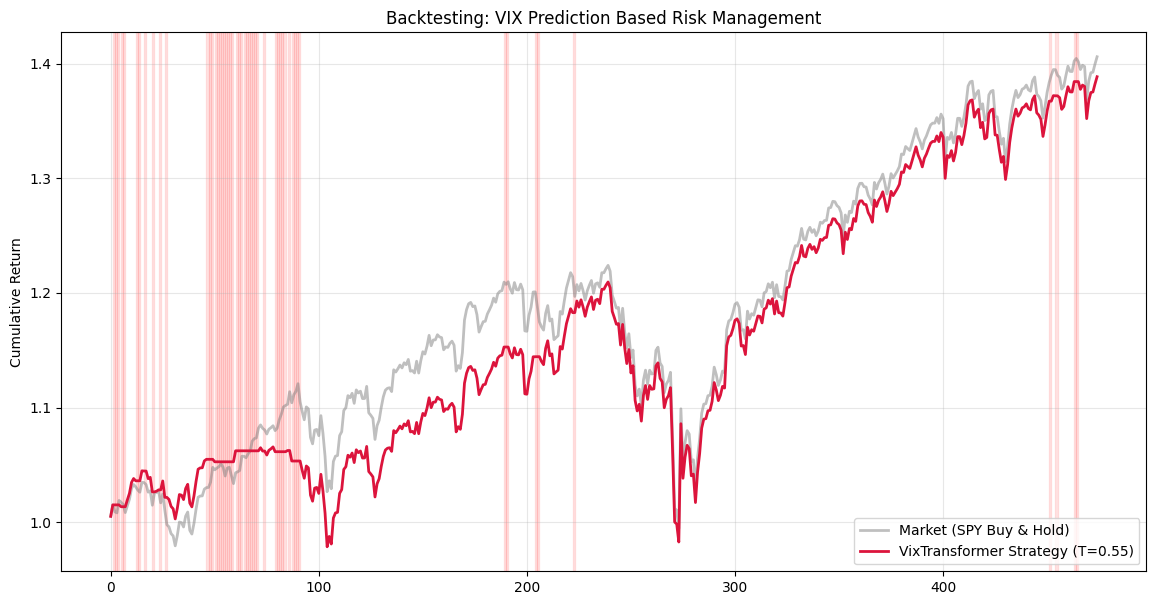

AttributeError: 'numpy.ndarray' object has no attribute 'cummax'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 모델의 상승 예측 확률 추출
model.eval()
with torch.no_grad():
    _, cls_p = model(X_ts[split:].to(device))
    rise_probs = torch.sigmoid(cls_p).cpu().numpy().flatten()

# 2. 전략 설정 (Threshold 튜닝 가능)
# 확률이 0.55를 넘으면 "위기"로 간주하고 시장에서 빠집니다 (현금화).
threshold = 0.55
signals = (rise_probs > threshold)

# 3. 수익률 데이터 정렬 (테스트 구간의 SPY 일일 수익률)
# 주의: t 시점의 예측으로 t+1 수익률을 결정하므로 시점을 1일 shift 합니다.
spy_returns = df['r_SPY'].iloc[-len(rise_probs):].values
strategy_returns = spy_returns.copy()

# 시그널이 발생한 다음 날은 수익률을 0으로 만듦 (현금 보유 상태)
# 실제 매매는 신호를 보고 그다음 날 아침에 이루어진다고 가정
strategy_returns[1:] = spy_returns[1:] * (~signals[:-1])

# 4. 누적 수익률 계산
cum_spy = np.exp(np.cumsum(spy_returns))
cum_strategy = np.exp(np.cumsum(strategy_returns))

# 5. 시각화
plt.figure(figsize=(14, 7))
plt.plot(cum_spy, label='Market (SPY Buy & Hold)', color='gray', alpha=0.5, linewidth=2)
plt.plot(cum_strategy, label=f'VixTransformer Strategy (T={threshold})', color='crimson', linewidth=2)

# 위기 감지 구역 표시 (배경색)
for i, s in enumerate(signals):
    if s:
        plt.axvspan(i, i+1, color='red', alpha=0.1)

plt.title("Backtesting: VIX Prediction Based Risk Management")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. 성과 지표 출력
mdd_spy = (cum_spy.cummax() - cum_spy).max() / cum_spy.cummax().max()
mdd_strat = (cum_strategy.cummax() - cum_strategy).max() / cum_strategy.cummax().max()

print(f"📊 [성과 리포트]")
print(f"최종 수익률: Market {cum_spy[-1]:.2f} vs Strategy {cum_strategy[-1]:.2f}")
print(f"최대 낙폭(MDD): Market {mdd_spy:.2%} vs Strategy {mdd_strat:.2%}")

In [ ]:
import numpy as np

def calculate_mdd(cum_returns):
    """
    Numpy array 기반의 누적 수익률을 입력받아 최대 낙폭(MDD)을 계산합니다.
    """
    # 현재 시점까지의 최고치(Peak)를 기록
    peak = np.maximum.accumulate(cum_returns)
    # 최고치 대비 현재 하락률 계산
    drawdown = (peak - cum_returns) / peak
    return np.max(drawdown)

def calculate_sharpe(returns, rf=0):
    """
    일간 수익률을 기반으로 연율화된 샤프 지수를 계산합니다. (252 영업일 기준)
    """
    if np.std(returns) == 0:
        return 0
    # (평균 수익률 / 표준편차) * 루트(252)
    return np.sqrt(252) * (np.mean(returns) - rf) / np.std(returns)

In [ ]:
# GARCH 모델용 최종 백테스팅 (T=0.50 적용 추천)
threshold = 0.50
signals = (rise_probs > threshold)

# 수익률 계산
strategy_returns = spy_returns.copy()
strategy_returns[1:] = spy_returns[1:] * (~signals[:-1])

cum_spy = np.exp(np.cumsum(spy_returns))
cum_strategy = np.exp(np.cumsum(strategy_returns))

# 지표 계산
mdd_strat = calculate_mdd(cum_strategy)
sharpe_strat = calculate_sharpe(strategy_returns)

print(f"🏆 [GARCH 전략 성과]")
print(f"최종 수익률: {cum_strategy[-1]:.2f}")
print(f"최대 낙폭(MDD): {mdd_strat:.2%}")
print(f"샤프 지수: {sharpe_strat:.2f}")

🏆 [GARCH 전략 성과]
최종 수익률: 1.32
최대 낙폭(MDD): 17.90%
샤프 지수: 1.00


# 뉴스기사

In [ ]:
pip install transformers torch

In [ ]:
import pandas as pd
import numpy as np
import requests # requests 임포트 확인

# [에러 해결 핵심] synced_idx를 판다스 시계열 형식으로 강제 변환
synced_idx = pd.to_datetime(synced_idx)

def fetch_optimized_news(api_key, synced_dates):
    all_news = []

    # 이제 .min()과 .strftime()이 정상 작동합니다.
    start_point = synced_dates.min().strftime('%Y%m%dT0000')

    # API 호출
    url = f'https://www.alphavantage.co/query?function=NEWS_SENTIMENT&limit=1000&apikey={api_key}'

    try:
        r = requests.get(url)
        data = r.json()

        if "feed" in data:
            for item in data['feed']:
                pub_time = pd.to_datetime(item['time_published'], format='%Y%m%dT%H%M%S')
                sentiment = item['overall_sentiment_score']
                relevance = item.get('relevance_score', 1.0)

                # 장 마감(16시) 이후 뉴스는 다음 거래일로 시차 적용
                effective_date = pub_time.date()
                if pub_time.hour >= 16:
                    effective_date = effective_date + pd.Timedelta(days=1)

                all_news.append({
                    'Date': pd.to_datetime(effective_date),
                    'WeightedSentiment': sentiment * relevance
                })

            df = pd.DataFrame(all_news)

            # 일별 평균 계산
            daily_sentiment = df.groupby('Date')['WeightedSentiment'].mean()

            # [결합] synced_dates 기준으로 정렬하고 없는 날은 0.0으로 채움
            final_sentiment = daily_sentiment.reindex(synced_dates).fillna(0.0)
            return final_sentiment

        else:
            print("❌ API 응답에 뉴스 데이터(feed)가 없습니다. 메시지:", data.get("Note", "N/A"))
            # 데이터가 없을 경우 0으로 가득 찬 Series 반환 (학습 중단 방지)
            return pd.Series(0.0, index=synced_dates)

    except Exception as e:
        print(f"❌ 에러 발생: {e}")
        return pd.Series(0.0, index=synced_dates)

# 다시 실행
daily_sentiment = fetch_optimized_news("GS4QU3FEJM95TR4V", synced_idx)

In [ ]:
daily_sentiment

,WeightedSentiment
2016-08-03,0.0
2016-08-04,0.0
2016-08-05,0.0
2016-08-08,0.0
2016-08-09,0.0
...,...
2026-02-04,0.0
2026-02-05,0.0
2026-02-06,0.0
2026-02-09,0.0


# kaggle에서 뉴스 데이터 가져오기
데이터 범위: 2016-08-03 00:00:00 ~ 2020-06-11 17:12:35-04:00


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
import numpy as np
import torch

def print_final_performance_report(model, val_loader, device, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for xb, _, ycb in val_loader:
            xb = xb.to(device)
            _, cls_p = model(xb)
            prob = torch.sigmoid(cls_p).cpu().numpy()
            all_probs.extend(prob)
            all_labels.extend(ycb.numpy())

    all_probs = np.array(all_probs).flatten()
    all_labels = np.array(all_labels).flatten()
    preds = (all_probs > threshold).astype(float)

    # --- [추가 지표 계산] ---
    auroc = roc_auc_score(all_labels, all_probs)
    auprc = average_precision_score(all_labels, all_probs) # 불균형 데이터에서 핵심!

    print("👑 [The Final Performance Report]")
    print(f"📊 AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}") # 모델의 전반적인 변별력 확인
    print("-" * 50)

    # digits=4로 설정하여 미세한 변화 감지
    report = classification_report(all_labels, preds, target_names=['Normal (0)', 'Crisis (1)'], digits=4)
    print(report)

    print("Confusion Matrix:")
    cm = confusion_matrix(all_labels, preds)
    # 가독성을 높인 출력
    print(f"               Predicted")
    print(f"               0         1")
    print(f"Actual 0:  [{cm[0,0]:5d} {cm[0,1]:5d}]  (정상인데 위기로 오보)")
    print(f"Actual 1:  [{cm[1,0]:5d} {cm[1,1]:5d}]  (위기인데 놓침/적중)")

    # 위기 탐지율(Recall) 강조 출력
    recall_1 = cm[1,1] / (cm[1,0] + cm[1,1] + 1e-9)
    print(f"\n📢 위기 탐지 성공률(Recall): {recall_1*100:.2f}%")


In [ ]:
import pandas as pd
import numpy as np
import os

# 1. 파일 경로 설정 (Kaggle 원본)
path = "/kaggle/input/massive-stock-news-analysis-db-for-nlpbacktests"
target_file = os.path.join(path, 'raw_analyst_ratings.csv')

# 2. 비교용 sync 날짜 세트 (문자열 리스트로 준비)
synced_date_strings = set(pd.to_datetime(synced_idx).strftime('%Y-%m-%d'))

print("📂 [완벽 보존 모드] 원본 문자열을 그대로 유지하며 필터링 중...")

try:
    # 3. 파일을 읽을 때 모든 컬럼을 '문자열(str)'로 읽도록 강제 (parse_dates 사용 금지)
    chunks = pd.read_csv(target_file, dtype=str, chunksize=300000)
    filtered_list = []

    for chunk in chunks:
        # [핵심] 원본 'date' 열은 건드리지 않고, 비교를 위해 앞 10자만 슬라이싱
        # 원본 예: "2020-06-05 10:30:54-04:00" -> 슬라이싱: "2020-06-05"
        mask = chunk['date'].str[:10].isin(synced_date_strings)

        if mask.any():
            # 필터링된 행만 복사 (이때 date는 여전히 원본 문자열임)
            filtered_chunk = chunk[mask].copy()
            # 불필요한 인덱스 열(Unnamed: 0)이 있다면 삭제
            if 'Unnamed: 0' in filtered_chunk.columns:
                filtered_chunk = filtered_chunk.drop(columns=['Unnamed: 0'])
            elif '' in filtered_chunk.columns: # 0번 인덱스가 이름 없을 때
                filtered_chunk = filtered_chunk.drop(columns=[''])

            filtered_list.append(filtered_chunk)

    # 4. 데이터 통합
    final_news_df = pd.concat(filtered_list, ignore_index=True)

    # 5. [중요] 정렬 (문자열 기준 정렬도 YYYY-MM-DD 형식이라 시간순으로 잘 정렬됨)
    final_news_df = final_news_df.sort_values(by='date').reset_index(drop=True)

    # 6. 저장 (비티메인 라스트 경로)
    save_path = "/content/drive/MyDrive/bitimin_last/synced_news_headlines_perfect_raw.csv"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    final_news_df.to_csv(save_path, index=False)

    print("-" * 50)
    print(f"✨ [성공] 원본 시/분/초가 박제된 파일 저장 완료!")
    print(f"📍 경로: {save_path}")
    print(f"📊 최종 데이터 개수: {len(final_news_df):,}개")

    # 7. 검증 출력 (슬라이싱 없이 생자로 출력)
    print("\n🔍 상위 10개 샘플 (문자열 상태 그대로):")
    for d in final_news_df['date'].head(10):
        print(f"원본 날짜값: {d}")
    print("-" * 50)

except Exception as e:
    print(f"❌ 에러 발생: {e}")

📂 [완벽 보존 모드] 원본 문자열을 그대로 유지하며 필터링 중...
❌ 에러 발생: [Errno 2] No such file or directory: '/kaggle/input/massive-stock-news-analysis-db-for-nlpbacktests/raw_analyst_ratings.csv'


In [ ]:
# 1. 마지막 날짜 데이터 추출 (시/분/초 포함)
last_date = final_news_df['date'].iloc[-1]

# 2. 결과 출력
print("-" * 30)
print(f"📅 뉴스 데이터의 마지막 날짜: {last_date}")
print("-" * 30)

# 3. (참고) 실제 확보된 날짜 수와 전체 데이터 기간 요약
print(f"📊 총 뉴스 건수: {len(final_news_df):,}건")
print(f"🕒 데이터 범위: {final_news_df['date'].iloc[0]} ~ {last_date}")

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm import tqdm

# 1. VADER 사전 및 도구 준비
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()
tqdm.pandas() # 진행 상태를 보기 위한 설정

def process_kaggle_sentiment_to_daily(file_path):
    print("📂 데이터를 불러오는 중...")
    df = pd.read_csv(file_path)

    # [단계 1] 감성 분석 수행 (-1 ~ 1 사이의 compound 점수 추출)
    print("🧪 57만 건 헤드라인 감성 분석 시작 (약 5분 소요)...")
    df['sentiment_score'] = df['headline'].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])

    # [단계 2] 시간 정보 정밀 파싱 (ISO8601 및 타임존 대응)
    print("🕒 미장 마감 시간(16:01) 기준 시프트 적용 중...")
    df['dt'] = pd.to_datetime(df['date'], format='ISO8601', utc=True).dt.tz_localize(None)

    # [단계 3] 장 마감 시프트 로직 적용
    # 16:01부터는 내일의 정보로 간주하여 날짜 +1
    df['adjusted_date'] = df['dt'].dt.normalize()
    # 16시 0분 0초 이후(즉 16:01부터) 발생하는 뉴스를 판별
    after_market_mask = (df['dt'].dt.hour > 16) | ((df['dt'].dt.hour == 16) & (df['dt'].dt.minute > 0))
    df.loc[after_market_mask, 'adjusted_date'] += pd.Timedelta(days=1)

    # [단계 4] 일일 평균 점수 계산 (하루에 숫자 1개로 압축)
    daily_sentiment = df.groupby('adjusted_date')['sentiment_score'].mean().reset_index()
    daily_sentiment.columns = ['Date', 'News_Sentiment_Score']

    return daily_sentiment

# 실행
file_input = "/content/drive/MyDrive/bitimin_last/synced_news_headlines_perfect_raw.csv"
final_kaggle_feature = process_kaggle_sentiment_to_daily(file_input)

# 저장
save_path = "/content/drive/MyDrive/bitimin_last/final_72nd_feature_kaggle_part.csv"
final_kaggle_feature.to_csv(save_path, index=False)

print("-" * 50)
print(f"✨ 72번째 피처(Kaggle 구간) 생성 완료!")
print(f"📊 기간: {final_kaggle_feature['Date'].min()} ~ {final_kaggle_feature['Date'].max()}")
print(f"💾 저장 경로: {save_path}")
display(final_kaggle_feature.head(10))

# api를 이용해서 나머지 날짜 뉴스 데이터 가져오기


In [ ]:
import requests
import pandas as pd
import time

def fetch_sentiment_only(api_key, start_date):
    """
    뉴스 텍스트 없이 감성 지수 데이터만 수집하여 효율화합니다.
    """
    # 2020-06-12부터 현재(2026-02-15)까지 수집
    url = f'https://www.alphavantage.co/query?function=NEWS_SENTIMENT&limit=1000&time_from={start_date}T0000&apikey={api_key}'

    try:
        r = requests.get(url)
        data = r.json()

        if "feed" in data:
            sentiment_data = []
            for item in data['feed']:
                # 날짜 정보만 추출 (시/분/초 유지)
                pub_time = pd.to_datetime(item['time_published'], format='%Y%m%dT%H%M%S')

                sentiment_data.append({
                    'date': pub_time,
                    'sentiment_score': float(item['overall_sentiment_score']) # 수치 데이터만 보존
                })

            df = pd.DataFrame(sentiment_data)
            # 시간순 정렬
            df = df.sort_values(by='date').reset_index(drop=True)
            return df
        else:
            print("⚠️ API 메시지:", data.get("Note", "데이터를 가져오지 못했습니다."))
            return pd.DataFrame()

    except Exception as e:
        print(f"❌ 에러 발생: {e}")
        return pd.DataFrame()

# API 키 및 시작 날짜 설정
api_key = "GS4QU3FEJM95TR4V"
# Kaggle 이후 날짜부터 수집
sentiment_only_df = fetch_sentiment_only(api_key, "20160803")

if not sentiment_only_df.empty:
    save_path = "/content/drive/MyDrive/bitimin_last/api_pure_sentiment_scores.csv"
    sentiment_only_df.to_csv(save_path, index=False)
    print(f"✅ 감성 지표(Score)만 추출하여 저장 완료: {save_path}")
    print(f"📊 수집된 지표 개수: {len(sentiment_only_df)}개")
    display(sentiment_only_df.head())

✅ 감성 지표(Score)만 추출하여 저장 완료: /content/drive/MyDrive/bitimin_last/api_pure_sentiment_scores.csv
📊 수집된 지표 개수: 1000개


,date,sentiment_score
0,2026-02-14 11:26:44,-0.128599
1,2026-02-14 11:26:50,0.231182
2,2026-02-14 11:26:53,0.046703
3,2026-02-14 11:27:00,0.068300
4,2026-02-14 11:27:05,0.876418


In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime

def fetch_news_bulk_logic(api_key, start_time_str):
    """
    하루 단위 조회가 아닌, 데이터가 있는 지점만 골라 1,000개씩 연속 수집합니다.
    """
    all_feeds = []
    # 시작 시간 형식: YYYYMMDDTHHMM
    current_pointer = start_time_str

    print(f"🚀 벌크 수집 시작 시점: {current_pointer}")

    # 예시로 20번 반복 (유료 키라면 숫자를 늘려 한 번에 다 가져올 수 있습니다)
    for i in range(20):
        url = f'https://www.alphavantage.co/query?function=NEWS_SENTIMENT&time_from={current_pointer}&limit=1000&sort=EARLIEST&apikey={api_key}'

        try:
            r = requests.get(url)
            data = r.json()

            if "feed" in data and data["feed"]:
                feed = data["feed"]
                all_feeds.extend(feed)

                # 마지막 뉴스의 발행 시각을 다음 호출의 시작점으로 업데이트
                last_time = feed[-1]['time_published']
                current_pointer = last_time

                print(f"📥 [{i+1}회차] {len(feed)}건 수집 완료 (마지막 시점: {last_time})")

                # 오늘 날짜 근처까지 왔으면 종료
                if last_time[:8] >= datetime.now().strftime('%Y%m%d'):
                    break
            else:
                print("🏁 더 이상 가져올 데이터가 없습니다.")
                break
        except Exception as e:
            print(f"❌ 오류 발생: {e}")
            break

        time.sleep(0.5) # 안정성을 위한 휴식

    # 데이터프레임 변환
    raw_df = pd.DataFrame([{
        'date': pd.to_datetime(f['time_published'], format='%Y%m%dT%H%M%S'),
        'sentiment_score': float(f['overall_sentiment_score'])
    } for f in all_feeds])

    return raw_df

# 실행
api_key = "GS4QU3FEJM95TR4V"
# 2020년 6월 12일 16시 01분부터 시작
raw_data = fetch_news_bulk_logic(api_key, "20200612T1601")

# 저장
raw_data.to_csv("/content/drive/MyDrive/bitimin_last/raw_api_bulk_data.csv", index=False)

🚀 벌크 수집 시작 시점: 20200612T1601
🏁 더 이상 가져올 데이터가 없습니다.


# 감정지수 포함해서 4년치 학습


In [ ]:
def create_forward_looking_sequences_rolling(features, targets_scaled, m_ret, s_idx, v_raw,
                                             seq_len=20, sync_threshold=0.9, p=6, window=2, lookback=252):
    X, y_reg, y_cls = [], [], []

    # Pandas Series로 변환 (롤링 계산을 위해)
    m_s = pd.Series(m_ret.flatten())
    v_raw_s = pd.Series(v_raw.flatten())

    # 1. VIX 변화율 계산
    vix_change = v_raw_s / (v_raw_s.shift(1) + 1e-9)

    # 2. 롤링 임계치 계산 (어제까지의 데이터를 기준으로 오늘의 '위험 기준선' 산출)
    # 하락장 하위 p% 기준선
    crash_limit = m_s.rolling(window=lookback, min_periods=100).quantile(p/100).shift(1)
    # VIX 급등 상위 p% 기준선
    panic_limit = vix_change.rolling(window=lookback, min_periods=100).quantile(1 - p/100).shift(1)

    # 3. 매일매일의 위기 여부 판별 (Hybrid AND 로직)
    # "동조화가 80% 이상이면서(&) 수익률이 최근 1년 대비 급락했거나, 공포가 급증했을 때"
    is_sync = (s_idx.flatten() >= sync_threshold)
    is_crash = (m_s <= crash_limit)
    is_panic = (vix_change >= panic_limit)

    # 최종 일일 위기 신호 (NaN은 False 처리)
    final_crisis_day = (is_sync & (is_crash | is_panic)).fillna(False).astype(int).values

    # 4. 시퀀스 생성 (기존 로직 유지)
    for i in range(len(features) - seq_len - window):
        idx = i + seq_len
        X.append(features[i : idx])
        y_reg.append(targets_scaled[idx])

        # 향후 window일 내에 '최종 위기'가 한 번이라도 발생하는가?
        future_windows = final_crisis_day[idx : idx + window]
        if np.any(future_windows == 1):
            y_cls.append(1)
        else:
            y_cls.append(0)

    return np.array(X), np.array(y_reg), np.array(y_cls)

In [ ]:
# ============================================================
# 2.5 부족한 데이터(Price, Volume) 다운로드 및 준비
# ============================================================
# df에 있는 종목 리스트 (예: 'AAPL', 'MSFT' 등)
end_dates_idx = pd.to_datetime(pd.Index(end_dates)).tz_localize(None).normalize()
ticker_list = df.columns.tolist()
start_date_str = end_dates_idx.min().strftime("%Y-%m-%d")
end_date_str   = end_dates_idx.max().strftime("%Y-%m-%d")

print(f"📥 {len(ticker_list)}개 종목의 종가 및 거래량 데이터 다운로드 시작...")

# 79개 종목의 데이터를 한꺼번에 다운로드
raw_data = yf.download(ticker_list, start=start_date_str, end=end_date_str, progress=False, auto_adjust=True)

df_price = raw_data['Close'].copy()
df_price.index = df_price.index.tz_localize(None).normalize()

df_volume = raw_data['Volume'].copy()
df_volume.index = df_volume.index.tz_localize(None).normalize()

# 만약 다운로드 중 결측치(NaN)가 있다면 이전 값으로 메움 (Forward Fill)


print("✅ 종가 및 거래량 데이터 준비 완료!")

📥 79개 종목의 종가 및 거래량 데이터 다운로드 시작...
✅ 종가 및 거래량 데이터 준비 완료!


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import StandardScaler

# ============================================================
# 0. 감성 분석 데이터 로드 (Kaggle 결과물)
# ============================================================
sentiment_df = pd.read_csv("/content/drive/MyDrive/bitimin_last/final_72nd_feature_kaggle_part.csv")
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.normalize()
sentiment_df.set_index('Date', inplace=True)

# ============================================================
# 1. 기존 데이터 로드
# ============================================================
H_concat = np.load("/content/drive/MyDrive/bitimin_last/H_concat_final.npy")
end_dates = np.load("/content/drive/MyDrive/bitimin_last/end_dates.npy", allow_pickle=True)
end_dates_idx = pd.to_datetime(pd.Index(end_dates)).tz_localize(None).normalize()

print(f"🚀 초기 데이터 로드 완료! H_concat: {H_concat.shape}")

# ============================================================
# 2. 날짜 범위 재설정 및 다운로드
# ============================================================
start_date_str = end_dates_idx.min().strftime("%Y-%m-%d")
end_date_str   = end_dates_idx.max().strftime("%Y-%m-%d")

vix_data = yf.download("^VIX", start=start_date_str, end=end_date_str, progress=False, auto_adjust=True)
gld_data = yf.download("GLD", start=start_date_str, end=end_date_str, progress=False, auto_adjust=True)

vix_raw = vix_data['Close'].squeeze().tz_localize(None)
vix_raw.index = vix_raw.index.normalize()

gld_raw = gld_data['Close'].squeeze().tz_localize(None)
gld_raw.index = gld_raw.index.normalize()

common_idx = end_dates_idx.intersection(vix_raw.index) \
                          .intersection(gld_raw.index) \
                          .intersection(sentiment_df.index)

synced_idx = sorted(common_idx)
print(f"✅ [동기화 완료] 최종 교집합 일수: {len(synced_idx)}일")


🚀 초기 데이터 로드 완료! H_concat: (2394, 79, 32)
✅ [동기화 완료] 최종 교집합 일수: 972일


In [ ]:
# ============================================================
# 2.6 TED Spread 대리 지표 (3-Month Treasury Bill) 다운로드
# ============================================================
print(f"📥 TED Spread 대리 지표(^IRX) 다운로드 중...")

# ^IRX: 3-Month Treasury Bill (국채 금리)
ted_proxy_data = yf.download("^IRX", start=start_date_str, end=end_date_str, progress=False, auto_adjust=True)

# 데이터 정제 및 인덱스 동기화
ted_raw = ted_proxy_data['Close'].squeeze().tz_localize(None)
ted_raw.index = ted_raw.index.normalize()


# [중요] 기존 synced_idx와의 교집합 재확인 (날짜가 어긋나면 안 됨)
# 이미 synced_idx가 계산된 상태라면 reindex를 통해 날짜를 맞춥니다.
ted_sync = ted_raw.reindex(synced_idx).values.reshape(-1, 1)


📥 TED Spread 대리 지표(^IRX) 다운로드 중...


In [ ]:
# 1. 결측치 상태 진단
from sklearn.decomposition import PCA

nan_count = np.isnan(ted_sync).sum()
inf_count = np.isinf(ted_sync).sum()

print(f"📋 [TED Spread 데이터 진단]")
print(f" - 전체 데이터 수: {len(ted_sync)}개")
print(f" - NaN 결측치 수: {nan_count}개")
print(f" - Inf 무한대 수: {inf_count}개")
ted_series = pd.Series(ted_sync.flatten(), index=synced_idx)
ted_filled = ted_series.ffill().bfill()  # 11/11 등 휴장일 결측치 해결
ted_sync = ted_filled.values.reshape(-1, 1)

# 4. 확인 출력
nan_check = np.isnan(ted_sync).sum()
print(f"✅ 11/11 결측치 처리 완료!")
print(f" - 처리 후 남은 NaN 개수: {nan_check}개")

📋 [TED Spread 데이터 진단]
 - 전체 데이터 수: 972개
 - NaN 결측치 수: 0개
 - Inf 무한대 수: 0개
✅ 11/11 결측치 처리 완료!
 - 처리 후 남은 NaN 개수: 0개


#### 검사

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# [추가] PCA 정보 보존율 점검
# ============================================================
max_check_dim = min(H_market_valid.shape[0], H_market_valid.shape[1], 100)  # 너무 크게 안 가게
pca_check = PCA(n_components=max_check_dim)
pca_check.fit(H_market_valid)

explained = pca_check.explained_variance_ratio_
cum_explained = np.cumsum(explained)

print("\n[ PCA Explained Variance Check ]")
for d in [8, 16, 32, 48, 64,128]:
    if d <= len(cum_explained):
        print(f"  - {d:2d} dims cumulative explained variance: {cum_explained[d-1]:.4f}")

# 목표 분산 비율에 필요한 차원 수
for th in [0.80, 0.90, 0.95, 0.99]:
    k = np.searchsorted(cum_explained, th) + 1
    print(f"  - dims needed for {int(th*100)}% variance: {k}")

# (선택) 시각화
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_explained)+1), cum_explained, marker='o', markersize=3)
plt.axhline(0.90, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.axvline(32, linestyle='--')
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.grid(True, alpha=0.3)
plt.show()


NameError: name 'H_market_valid' is not defined

In [ ]:

# ============================================================
# 3. 동기화된 인덱스 기반 피처 필터링 (유동성 피처 추가)
# ============================================================
# (1) VIX & GLD
vix_values = vix_raw.reindex(synced_idx).values.reshape(-1, 1)
vix_log_ret = np.log(vix_values[1:] / (vix_values[:-1] + 1e-9))
vix_log_ret = np.insert(vix_log_ret, 0, 0).reshape(-1, 1)

gld_values = gld_raw.reindex(synced_idx).values.reshape(-1, 1)
gld_log_ret = np.log(gld_values[1:] / (gld_values[:-1] + 1e-9))
gld_log_ret = np.insert(gld_log_ret, 0, 0).reshape(-1, 1)

# (2) [신규] 유동성 리스크 피처 계산 (Relative Volume & Amihud)
# df, df_price, df_volume은 사전에 준비되어 있어야 합니다.
df.index = pd.to_datetime(df.index).normalize()
df_price.index = pd.to_datetime(df_price.index).normalize()
df_volume.index = pd.to_datetime(df_volume.index).normalize()

# 1. 상대 거래량 (Relative Volume): 오늘 거래량 / 최근 20일 평균 거래량
# rel_vol_all = df_volume / (df_volume.rolling(window=20).mean() + 1e-9)
# rel_vol_sync = rel_vol_all.reindex(synced_idx).mean(axis=1).values.reshape(-1, 1)

# 2. Amihud 유동성 지표: |수익률| / (가격 * 거래량) -> 시장 평균
turnover = df_price * df_volume
amihud_all = np.abs(df) / (turnover + 1e-12)
amihud_sync = amihud_all.reindex(synced_idx).mean(axis=1).values.reshape(-1, 1)

# (3) ETF 수익률 및 동조화 지수
market_avg_ret = df.reindex(synced_idx).mean(axis=1).values.reshape(-1, 1)
sync_index = ((df.reindex(synced_idx) < 0).sum(axis=1).values / (df.shape[1] + 1e-9)).reshape(-1, 1)

# (4) 네트워크 임베딩 필터링
valid_mask = end_dates_idx.isin(synced_idx)
H_flat = H_concat.reshape(H_concat.shape[0], -1)
H_market_valid = H_flat[valid_mask]

# (5) 감성 분석 피처 (72번째 컬럼)
sentiment_values = sentiment_df.reindex(synced_idx).values.reshape(-1, 1)

pca = PCA(n_components=32)
H_pca = pca.fit_transform(H_market_valid)

print(f"✅ H_market_valid 압축 완료: {H_market_valid.shape[1]}차원 -> {H_pca.shape[1]}차원")

# ============================================================
# 4. 최종 결합 (유동성 피처 통합)
# ============================================================
# H_final_input = np.concatenate([
#     StandardScaler().fit_transform(H_pca),
#     # StandardScaler().fit_transform(H_market_valid),   # GCN 임베딩 (고차원)
#     StandardScaler().fit_transform(vix_log_ret),     # VIX 변화율
#     #StandardScaler().fit_transform(sync_index),      # 동조화 지수
#     StandardScaler().fit_transform(gld_log_ret),     # 금 수익률
#     StandardScaler().fit_transform(sentiment_values), # 뉴스 감성
#     StandardScaler().fit_transform(amihud_sync),      # Amihud 지표 (신규)
#     StandardScaler().fit_transform(ted_sync)
# ], axis=-1)


vix_final = pd.Series(vix_log_ret.flatten(), index=synced_idx).reindex(synced_idx).values.reshape(-1, 1)
gld_final = pd.Series(gld_log_ret.flatten(), index=synced_idx).reindex(synced_idx).values.reshape(-1, 1)

# 2. 감성 분석 및 유동성 지표
sent_final = sentiment_df.reindex(synced_idx).values.reshape(-1, 1)
ami_final  = amihud_all.reindex(synced_idx).mean(axis=1).values.reshape(-1, 1)

# 3. TED Spread (이미 synced_idx로 처리된 ted_series 활용)

ted_series_final = pd.Series(ted_sync.flatten())
ted_final = ted_series_final.reindex(range(len(synced_idx))).ffill().bfill().fillna(0).values.reshape(-1, 1)
print(f"📊 규격 확인: H_pca({H_pca.shape[0]}) == 매크로들({vix_final.shape[0]})")

# [결합] 이제 모든 차원의 0번 축이 972로 동일하므로 에러가 나지 않습니다.
H_final_input = np.concatenate([
    StandardScaler().fit_transform(H_pca),           # 압축된 GCN 피처 (32차원)
    StandardScaler().fit_transform(vix_final),       # VIX
    StandardScaler().fit_transform(gld_final),       # 금
    StandardScaler().fit_transform(sent_final),      # 감성
    StandardScaler().fit_transform(ami_final),       # Amihud
    StandardScaler().fit_transform(ted_final)        # TED
], axis=-1)

# ============================================================
# 5. 시퀀스 생성 및 라벨링
# ============================================================
scaler_target = StandardScaler()
vix_scaled = scaler_target.fit_transform(vix_values)
print(f"🚀 데이터 결합 완료! 최종 피처 차원: {H_final_input.shape}")

X_np, y_reg_np, y_cls_np = create_forward_looking_sequences_rolling(
    features=H_final_input,
    targets_scaled=vix_scaled,
    m_ret=market_avg_ret,
    s_idx=sync_index,
    v_raw=vix_values,
    seq_len=20,
    sync_threshold=0.9, # 동조화 기준 (0.9로 강화)
    p=6,                # 최근 1년 대비 하위 5% 수익률
    window=2,
    lookback=252
)

# ============================================================
# 6. 최종 데이터셋 통계 출력
# ============================================================
total_samples = len(y_cls_np)
crisis_days = int(np.sum(y_cls_np))
normal_days = total_samples - crisis_days
crisis_ratio = (crisis_days / total_samples) * 100

print("-" * 40)
print(f"📢 [데이터셋 통계] 시스템 리스크 탐지 라벨링 결과")
print("-" * 40)
print(f"✅ 전체 학습 샘플(Sequence) 수: {total_samples}개")
print(f"🚨 위기 발생 상황 (Label 1): {crisis_days}개")
print(f"🟢 정상 운영 상황 (Label 0): {normal_days}개")
print(f"📈 위기 데이터 비중: {crisis_ratio:.2f}%")
print("-" * 40)

if crisis_days < 10:
    print("⚠️ 경고: 위기 샘플이 너무 부족합니다. p값을 높이거나 sync_threshold를 조절하세요.")

✅ H_market_valid 압축 완료: 2528차원 -> 32차원
📊 규격 확인: H_pca(972) == 매크로들(972)
🚀 데이터 결합 완료! 최종 피처 차원: (972, 37)
----------------------------------------
📢 [데이터셋 통계] 시스템 리스크 탐지 라벨링 결과
----------------------------------------
✅ 전체 학습 샘플(Sequence) 수: 950개
🚨 위기 발생 상황 (Label 1): 78개
🟢 정상 운영 상황 (Label 0): 872개
📈 위기 데이터 비중: 8.21%
----------------------------------------


In [ ]:
y_cls_np

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
print(f"H_flat의 원래 날짜 수: {len(H_flat)}") # 2394 예상
print(f"valid_mask 내 True의 수: {sum(valid_mask)}") # 972 예상
print(f"최종 필터링된 H_market_valid의 수: {len(H_market_valid)}") # 972 예상

H_flat의 원래 날짜 수: 2394
valid_mask 내 True의 수: 972
최종 필터링된 H_market_valid의 수: 972


In [ ]:
import torch
import torch.nn as nn

import math
import torch
import torch.nn as nn

class VixTransformer(nn.Module):
    def __init__(self, input_dim=34, model_dim=64, n_heads=8, n_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, model_dim)

        # --- [수정] Sinusoidal Positional Encoding 생성 로직 ---
        max_len = 20
        pe = torch.zeros(max_len, model_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, model_dim, 2).float() * (-math.log(10000.0) / model_dim))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # (1, 20, model_dim)

        # register_buffer는 이 값이 가중치처럼 업데이트되지 않도록 고정하면서,
        # model.to(device) 호출 시 함께 이동하게 해줍니다.
        self.register_buffer('pos_encoding', pe)
        # --------------------------------------------------

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=n_heads, dim_feedforward=model_dim*4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=n_layers)

        self.reg_head = nn.Sequential(
            nn.Linear(model_dim, model_dim // 2), nn.ReLU(), nn.Linear(model_dim // 2, 1)
        )
        self.cls_head = nn.Sequential(
            nn.Linear(model_dim, model_dim // 2), nn.ReLU(), nn.Linear(model_dim // 2, 1)
        )

    def forward(self, x):
        recent_signal = self.embedding(x[:, -1, :])

        x = self.embedding(x) + self.pos_encoding[:, :x.size(1), :]
        x = self.transformer(x)
        last_h = x[:, -1, :]

        # [솔루션] Transformer 결과에 최근 신호를 직접 더함 (잔차 연결)
        combined_h = last_h + recent_signal

        reg_out = self.reg_head(combined_h)
        cls_out = self.cls_head(combined_h)
        return reg_out, cls_out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# X: (Samples, 20, 72) 형태로 변환됩니다.
X_ts = torch.tensor(X_np, dtype=torch.float32)
y_reg_ts = torch.tensor(y_reg_np, dtype=torch.float32)
y_cls_ts = torch.tensor(y_cls_np, dtype=torch.float32).view(-1, 1)

# ============================================================
# 3. 모델 인스턴스화 (72차원 자동 적용)
# ============================================================
# X_ts.shape[-1]이 72이므로, 모델의 input_dim은 자동으로 72가 됩니다.
model = VixTransformer(
    input_dim=X_ts.shape[-1],
    model_dim=128,
    n_heads=8,      # Optuna 추천값 반영
    n_layers=2,
    dropout=0.319
).to(device)

print(f"🚀 모델 준비 완료! 입력 차원: {X_ts.shape[-1]}")
print(f"📊 학습 시퀀스 개수: {len(X_ts)}")


🚀 모델 준비 완료! 입력 차원: 37
📊 학습 시퀀스 개수: 950


In [ ]:
from torch.utils.data import DataLoader, TensorDataset, Subset


# ============================================================
# 2. 데이터셋 분할 (8:2 비율, 시계열 순서 유지)
# ============================================================
total_len = len(X_ts)
split_idx = int(total_len * 0.8)

full_dataset = TensorDataset(X_ts, y_reg_ts, y_cls_ts)

# 시계열 데이터이므로 shuffle=False로 분할 인덱스 생성
train_indices = np.arange(split_idx)
val_indices = np.arange(split_idx, total_len)

# [해결 핵심] Optuna와 학습 루프에서 사용할 로더 정의
train_loader = DataLoader(Subset(full_dataset, train_indices), batch_size=32, shuffle=True)
val_loader = DataLoader(Subset(full_dataset, val_indices), batch_size=32, shuffle=False)

print(f"✅ 데이터 로더 생성 완료!")
print(f"📂 Train samples: {len(train_indices)} | Val samples: {len(val_indices)}")
print("-" * 30)

✅ 데이터 로더 생성 완료!
📂 Train samples: 760 | Val samples: 190
------------------------------


In [ ]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna
import numpy as np
from sklearn.metrics import f1_score, balanced_accuracy_score, precision_score
# 가중치 초기화 함수
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

# 1. Focal Loss (alpha를 0.8로 상향하여 위기 탐지 강화)
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        # alpha가 없으면 기본 0.75, 있으면 해당 값 사용
        self.alpha = alpha if alpha is not None else 0.75
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # [Logit Shift 아이디어 적용 가능 지점]
        # logits = logits - 0.1  # 정밀도를 극단적으로 높이고 싶을 때 주석 해제

        p = torch.sigmoid(logits)
        # Numerical Stability를 위해 직접 계산 대신 binary_cross_entropy_with_logits 활용
        ce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

        pt = torch.where(targets == 1, p, 1 - p)
        # 아래 식은 어려운 문제일수록 (1-pt)가 커져서 손실값이 증폭됨
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_t * (1 - pt).pow(self.gamma) * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        return loss.sum()

def log_cosh_loss(y_pred, y_true):
    return torch.mean(torch.log(torch.cosh(y_pred - y_true + 1e-12)))

def objective(trial):
    # 1. 학습 하이퍼파라미터
    lr = trial.suggest_float("lr", 5e-6, 5e-5, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)

    # 2. 모델 구조 하이퍼파라미터
    m_dim = 64
    n_heads = trial.suggest_categorical("n_heads", [4, 8])
    drop_out = trial.suggest_float("dropout", 0.3, 0.5)

    # 3. 손실 함수 하이퍼파라미터 (alpha 추가!)
    gamma = trial.suggest_float("gamma", 2.0, 5.0)
    # alpha: 위기(1)에 부여할 가중치. 0.6~0.9 사이에서 최적값 탐색
    alpha = trial.suggest_float("alpha", 0.6, 0.9)
    # 전체 분류 손실의 비중
    alpha_cls_weight = trial.suggest_float("alpha_cls_weight", 5.0, 15.0)

    local_model = VixTransformer(
        input_dim=X_ts.shape[-1],
        model_dim=m_dim,
        n_heads=n_heads,
        dropout=drop_out
    ).to(device)
    local_model.apply(init_weights)

    # Optuna가 찾은 alpha와 gamma 적용
    criterion_cls = FocalLoss(alpha=alpha, gamma=gamma).to(device)
    optimizer = torch.optim.AdamW(local_model.parameters(), lr=lr, weight_decay=weight_decay)

    best_trial_score = 0

    for ep in range(1, 51):
        local_model.train()
        for xb, yrb, ycb in train_loader:
            xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
            optimizer.zero_grad()
            reg_p, cls_p = local_model(xb)

            # alpha_cls_weight 적용
            loss = log_cosh_loss(reg_p, yrb) + alpha_cls_weight * criterion_cls(cls_p, ycb)
            loss.backward()
            optimizer.step()

        local_model.eval()
        val_probs, val_targets = [], []
        with torch.no_grad():
            for xb, _, ycb in val_loader:
                _, cls_p = local_model(xb.to(device))
                val_probs.extend(torch.sigmoid(cls_p).cpu().numpy())
                val_targets.extend(ycb.numpy())

        # 성능 평가 시 "정밀도"에 더 높은 가중치를 둡니다.
        val_probs = np.array(val_probs).flatten()
        val_targets = np.array(val_targets).flatten()

        # 최적 임계값 탐색 범위를 정밀도가 보장되는 0.3~0.7로 상향
        ts = np.linspace(0.3, 0.7, 21)
        trial_f1s = [f1_score(val_targets, (val_probs > t).astype(int), zero_division=0) for t in ts]

        current_max_f1 = max(trial_f1s)
        if current_max_f1 > best_trial_score:
            best_trial_score = current_max_f1

    return best_trial_score

# 3. 최적화 실행
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("-" * 30)
print("Best Parameters:", study.best_params)

# 4. 최종 학습 (Best Params 반영)
# 4. 최종 학습 (Best Params 반영 + 정밀도 최적화 튜닝)
# 4. 최종 학습 (Best Params 반영 + 차원 정합성 보장)
best = study.best_params
# ============================================================
# 3. Best Params 기반 최종 재학습 (핵심 수정 부분)
# ============================================================
best = study.best_params

# Optuna에서 찾은 값들을 모두 반영
best_lr = best["lr"]
best_weight_decay = best["weight_decay"]
best_n_heads = best["n_heads"]
best_dropout = best["dropout"]
best_gamma = best["gamma"]
best_alpha = best["alpha"]
best_alpha_cls_weight = best["alpha_cls_weight"]

# model_dim은 search 안 했으므로 고정
best_model_dim = 64

model = VixTransformer(
    input_dim=X_ts.shape[-1],
    model_dim=best_model_dim,
    n_heads=best_n_heads,
    dropout=best_dropout
).to(device)
model.apply(init_weights)


criterion_cls = FocalLoss(alpha=best_alpha, gamma=best_gamma).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr,
    weight_decay=best_weight_decay
)

best_model_wts = copy.deepcopy(model.state_dict())
best_val_score = -1.0
final_best_t = 0.5
counter = 0
patience = 25
max_epochs = 150

for ep in range(1, max_epochs + 1):
    # ---- train ----
    model.train()
    train_loss_epoch = 0.0
    num_batches = 0

    for xb, yrb, ycb in train_loader:
        xb = xb.to(device)
        yrb = yrb.to(device).float()
        ycb = ycb.to(device).float()

        optimizer.zero_grad()
        reg_p, cls_p = model(xb)

        loss_reg = log_cosh_loss(reg_p, yrb)
        loss_cls = criterion_cls(cls_p, ycb)
        loss = loss_reg + best_alpha_cls_weight * loss_cls

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss_epoch += loss.item()
        num_batches += 1

    avg_train_loss = train_loss_epoch / max(num_batches, 1)

    # ---- val ----
    model.eval()
    val_probs, val_targets = [], []
    with torch.no_grad():
        for xb, _, ycb in val_loader:
            xb = xb.to(device)
            _, cls_p = model(xb)

            val_probs.extend(torch.sigmoid(cls_p).cpu().numpy().reshape(-1))
            val_targets.extend(ycb.numpy().reshape(-1))

    val_probs = np.array(val_probs).flatten()
    val_targets = np.array(val_targets).flatten().astype(int)

    # threshold search
    thresholds = np.linspace(0.2, 0.7, 51)
    scores = [
        f1_score(val_targets, (val_probs > t).astype(int), zero_division=0)
        for t in thresholds
    ]

    current_max_f1 = float(np.max(scores))
    current_t = float(thresholds[int(np.argmax(scores))])

    if current_max_f1 > best_val_score:
        best_val_score = current_max_f1
        final_best_t = current_t
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if ep % 10 == 0 or ep == 1:
        print(
            f"Epoch {ep:3d} | TrainLoss: {avg_train_loss:.4f} "
            f"| Best Val F1: {best_val_score:.4f} | Best T: {final_best_t:.2f} | Patience: {counter}"
        )

    if counter >= patience:
        print(f"🛑 Early stopping at epoch {ep}")
        break

# best weight 복원
model.load_state_dict(best_model_wts)

print(f"\n✅ Best params 재학습 완료")
print(f"   - Best Val F1: {best_val_score:.4f}")
print(f"   - Best Threshold: {final_best_t:.4f}")

# 최종 성능 리포트
print_final_performance_report(model, val_loader, device, threshold=final_best_t)

[I 2026-02-22 17:32:35,127] A new study created in memory with name: no-name-cb8978f8-54ce-47d0-863a-5be84d23ad6d
[I 2026-02-22 17:33:26,632] Trial 0 finished with value: 0.3548387096774194 and parameters: {'lr': 3.560891562398915e-05, 'weight_decay': 0.00023581154945940015, 'n_heads': 8, 'dropout': 0.3454814918057416, 'gamma': 4.916262362927154, 'alpha': 0.8772270274926989, 'alpha_cls_weight': 6.189604416276656}. Best is trial 0 with value: 0.3548387096774194.
[I 2026-02-22 17:34:12,486] Trial 1 finished with value: 0.5818181818181818 and parameters: {'lr': 6.559058687187819e-06, 'weight_decay': 0.0001943473162987945, 'n_heads': 4, 'dropout': 0.41392758299646937, 'gamma': 4.788373121430029, 'alpha': 0.6348853078851753, 'alpha_cls_weight': 11.255548316013865}. Best is trial 1 with value: 0.5818181818181818.
[I 2026-02-22 17:34:57,727] Trial 2 finished with value: 0.2774566473988439 and parameters: {'lr': 6.445334684531682e-06, 'weight_decay': 0.0028072616374699546, 'n_heads': 4, 'dropo

------------------------------
Best Parameters: {'lr': 6.559058687187819e-06, 'weight_decay': 0.0001943473162987945, 'n_heads': 4, 'dropout': 0.41392758299646937, 'gamma': 4.788373121430029, 'alpha': 0.6348853078851753, 'alpha_cls_weight': 11.255548316013865}
Epoch   1 | TrainLoss: 1.8920 | Best Val F1: 0.2427 | Best T: 0.20 | Patience: 0
Epoch  10 | TrainLoss: 1.0351 | Best Val F1: 0.2427 | Best T: 0.20 | Patience: 9
Epoch  20 | TrainLoss: 0.6621 | Best Val F1: 0.2427 | Best T: 0.20 | Patience: 19
🛑 Early stopping at epoch 26

✅ Best params 재학습 완료
   - Best Val F1: 0.2427
   - Best Threshold: 0.2000
👑 [The Final Performance Report]
📊 AUROC: 0.3247 | AUPRC: 0.1198
--------------------------------------------------
              precision    recall  f1-score   support

  Normal (0)     0.6923    0.0559    0.1034       161
  Crisis (1)     0.1412    0.8621    0.2427        29

    accuracy                         0.1789       190
   macro avg     0.4168    0.4590    0.1731       190
weig

In [ ]:
def plot_vix_with_detection_points(vix_raw, result_df, title_suffix=""):
    """
    vix_raw: pd.Series (index=date, value=VIX)
    result_df: columns = ['date', 'y_true', 'y_prob', 'y_pred', 'case']
    """
    import pandas as pd
    import matplotlib.pyplot as plt

    # --- 0) 입력 확인 ---
    if "date" not in result_df.columns:
        print("[DEBUG] result_df columns:", list(result_df.columns))
        raise KeyError("result_df에 'date' 컬럼이 없습니다. get_val_predictions_with_dates 결과를 확인하세요.")

    # --- 1) VIX 시계열 정리 ---
    vix_plot = vix_raw.copy()
    vix_plot.index = pd.to_datetime(vix_plot.index).normalize()
    vix_plot = vix_plot.sort_index()

    # validation 구간만 자르기
    tmp_result = result_df.copy()
    tmp_result["date"] = pd.to_datetime(tmp_result["date"]).dt.normalize()

    date_min = tmp_result["date"].min()
    date_max = tmp_result["date"].max()
    vix_plot = vix_plot.loc[(vix_plot.index >= date_min) & (vix_plot.index <= date_max)]

    # --- 2) merge용 VIX dataframe 생성 (컬럼명 강제 지정) ---
    # 핵심 수정: reset_index 후 컬럼명을 직접 덮어쓰기
    vix_df = vix_plot.reset_index()
    vix_df.columns = ["date", "VIX"]   # <= 이걸로 컬럼명 문제 완전히 방지
    vix_df["date"] = pd.to_datetime(vix_df["date"]).dt.normalize()

    # --- 3) merge ---
    tmp = tmp_result.merge(vix_df, on="date", how="left")

    # 혹시 결측 확인
    if tmp["VIX"].isna().any():
        na_cnt = int(tmp["VIX"].isna().sum())
        print(f"[WARN] VIX 매칭 안 된 날짜 {na_cnt}개 있음 (휴장일/인덱스 불일치 가능)")
        # 필요시 drop
        # tmp = tmp.dropna(subset=["VIX"]).copy()

    tp = tmp[tmp["case"] == "TP"]   # 위기 적중
    fn = tmp[tmp["case"] == "FN"]   # 위기 놓침
    fp = tmp[tmp["case"] == "FP"]   # 정상인데 오보

    # --- 4) plot ---
    plt.figure(figsize=(14, 5))
    plt.plot(vix_plot.index, vix_plot.values, label="VIX", linewidth=1.5)

    # 요청사항: TP를 빨간 점으로 표시
    plt.scatter(tp["date"], tp["VIX"], s=50, marker="o", label="TP (Crisis Hit)", zorder=3)

    # 참고용
    if len(fn) > 0:
        plt.scatter(fn["date"], fn["VIX"], s=45, marker="x", label="FN (Missed Crisis)", zorder=3)
    if len(fp) > 0:
        plt.scatter(fp["date"], fp["VIX"], s=35, marker="^", label="FP (False Alarm)", zorder=3)

    plt.title(f"VIX with Crisis Detection Points {title_suffix}")
    plt.xlabel("Date")
    plt.ylabel("VIX")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("TP count:", len(tp), "| FN count:", len(fn), "| FP count:", len(fp))
    return tmp


In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# ============================================================
# [A] baseline 성능 계산 함수
# ============================================================
def evaluate_cls_only(model, loader, device, threshold=0.5):
    model.eval()
    probs, targets = [], []
    with torch.no_grad():
        for xb, _, ycb in loader:
            xb = xb.to(device)
            _, cls_p = model(xb)
            probs.extend(torch.sigmoid(cls_p).cpu().numpy().reshape(-1))
            targets.extend(ycb.numpy().reshape(-1))

    probs = np.array(probs)
    targets = np.array(targets).astype(int)
    preds = (probs > threshold).astype(int)

    return {
        "f1": f1_score(targets, preds, zero_division=0),
        "recall": recall_score(targets, preds, zero_division=0),
        "precision": precision_score(targets, preds, zero_division=0),
        "targets": targets,
        "probs": probs
    }

# ============================================================
# [B] validation subset 텐서를 직접 구성 (퍼뮤테이션용)
# ============================================================
def build_val_tensors_from_full_dataset(full_dataset, val_indices):
    X_list, yr_list, yc_list = [], [], []
    for idx in val_indices:
        x, yr, yc = full_dataset[idx]
        # tensor/np 모두 대응
        X_list.append(x.unsqueeze(0) if torch.is_tensor(x) else torch.tensor(x).unsqueeze(0))
        yr_list.append(yr.unsqueeze(0) if torch.is_tensor(yr) else torch.tensor([yr]))
        yc_list.append(yc.unsqueeze(0) if torch.is_tensor(yc) else torch.tensor([yc]))

    X_val = torch.cat(X_list, dim=0).float()
    yreg_val = torch.cat(yr_list, dim=0).float()
    ycls_val = torch.cat(yc_list, dim=0).float()
    return X_val, yreg_val, ycls_val

# ============================================================
# [C] 퍼뮤테이션 중요도 계산 (72개 피처)
# ============================================================
def permutation_importance_timeseries(
    model,
    X_val, yreg_val, ycls_val,
    device,
    threshold=0.5,
    batch_size=32,
    feature_names=None,
    metric="f1",
    n_repeats=3,
    random_state=42
):
    """
    X_val shape: [N, T, F] 또는 [N, F]
    metric: "f1" / "recall" / "precision"
    """
    rng = np.random.RandomState(random_state)

    base_loader = DataLoader(TensorDataset(X_val, yreg_val, ycls_val), batch_size=batch_size, shuffle=False)
    base_scores = evaluate_cls_only(model, base_loader, device, threshold)
    base_metric = base_scores[metric]

    X_np = X_val.cpu().numpy()
    n_samples = X_np.shape[0]
    n_features = X_np.shape[-1]

    results = []

    for f_idx in range(n_features):
        drops = []

        for _ in range(n_repeats):
            X_perm = X_np.copy()

            # 샘플 축 permutation (시간축 구조는 유지, 특정 feature만 샘플 간 섞음)
            perm_idx = rng.permutation(n_samples)

            if X_perm.ndim == 3:
                # [N, T, F]
                X_perm[:, :, f_idx] = X_perm[perm_idx, :, f_idx]
            elif X_perm.ndim == 2:
                # [N, F]
                X_perm[:, f_idx] = X_perm[perm_idx, f_idx]
            else:
                raise ValueError(f"Unsupported X shape: {X_perm.shape}")

            perm_loader = DataLoader(
                TensorDataset(torch.tensor(X_perm).float(), yreg_val, ycls_val),
                batch_size=batch_size,
                shuffle=False
            )
            perm_scores = evaluate_cls_only(model, perm_loader, device, threshold)
            drop = base_metric - perm_scores[metric]  # 성능 감소량
            drops.append(drop)

        results.append({
            "feature_idx": f_idx,
            "feature_name": feature_names[f_idx] if feature_names is not None else f"feat_{f_idx}",
            f"importance_{metric}_drop_mean": float(np.mean(drops)),
            f"importance_{metric}_drop_std": float(np.std(drops)),
            "base_metric": float(base_metric)
        })

    imp_df = pd.DataFrame(results).sort_values(f"importance_{metric}_drop_mean", ascending=False).reset_index(drop=True)
    return imp_df, base_scores


In [ ]:
X_val_tensor, yreg_val_tensor, ycls_val_tensor = build_val_tensors_from_full_dataset(full_dataset, val_indices)

print("X_val_tensor shape:", X_val_tensor.shape)   # 기대: [N, T, 72]
print("ycls_val_tensor shape:", ycls_val_tensor.shape)
feature_names = (
    [f"gcn_pca_{i}" for i in range(32)] +
    ["vix", "gld", "sentiment", "amihud", "ted_spread"]
)



X_val_tensor shape: torch.Size([190, 20, 37])
ycls_val_tensor shape: torch.Size([190, 1])


In [ ]:
imp_f1_df, base_scores = permutation_importance_timeseries(
    model=model,
    X_val=X_val_tensor,
    yreg_val=yreg_val_tensor,
    ycls_val=ycls_val_tensor,
    device=device,
    threshold=final_best_t,
    batch_size=32,
    feature_names=feature_names,
    metric="f1",
    n_repeats=5,
    random_state=42
)

print("Baseline scores:", {k: v for k, v in base_scores.items() if k in ["f1", "recall", "precision"]})
display(imp_f1_df.head(100))


Baseline scores: {'f1': 0.36538461538461536, 'recall': 0.6551724137931034, 'precision': 0.25333333333333335}


,feature_idx,feature_name,importance_f1_drop_mean,importance_f1_drop_std,base_metric
0,29,gcn_pca_29,0.071896,0.011569,0.365385
1,12,gcn_pca_12,0.066922,0.008002,0.365385
2,8,gcn_pca_8,0.043843,0.019588,0.365385
3,23,gcn_pca_23,0.042116,0.012474,0.365385
4,15,gcn_pca_15,0.036227,0.026802,0.365385
5,13,gcn_pca_13,0.032875,0.013573,0.365385
6,11,gcn_pca_11,0.032663,0.011234,0.365385
7,33,gld,0.032037,0.012880,0.365385
8,18,gcn_pca_18,0.029716,0.016561,0.365385
9,27,gcn_pca_27,0.029687,0.012903,0.365385


In [ ]:
imp_recall_df, _ = permutation_importance_timeseries(
    model=model,
    X_val=X_val_tensor,
    yreg_val=yreg_val_tensor,
    ycls_val=ycls_val_tensor,
    device=device,
    threshold=final_best_t,
    batch_size=32,
    feature_names=feature_names,
    metric="recall",     # 위기탐지 목적이면 이거도 꼭 보자
    n_repeats=5,
    random_state=42
)

display(imp_recall_df.head(20))


,feature_idx,feature_name,importance_recall_drop_mean,importance_recall_drop_std,base_metric
0,35,feat_35,0.144828,0.059326,0.896552
1,8,feat_8,0.131034,0.033786,0.896552
2,22,feat_22,0.124138,0.035166,0.896552
3,6,feat_6,0.124138,0.035166,0.896552
4,12,feat_12,0.110345,0.033786,0.896552
5,3,feat_3,0.089655,0.035166,0.896552
6,17,feat_17,0.075862,0.040213,0.896552
7,13,feat_13,0.068966,0.000000,0.896552
8,0,feat_0,0.068966,0.021809,0.896552
9,24,feat_24,0.062069,0.013793,0.896552


In [ ]:
import numpy as np
import pandas as pd
import torch

def get_val_result_df(model, val_loader, val_indices, end_dates_idx, device, threshold):
    model.eval()
    probs, targets = [], []

    with torch.no_grad():
        for xb, _, ycb in val_loader:
            xb = xb.to(device)
            _, cls_p = model(xb)
            probs.extend(torch.sigmoid(cls_p).cpu().numpy().reshape(-1))
            targets.extend(ycb.cpu().numpy().reshape(-1))

    probs = np.array(probs).astype(float)
    targets = np.array(targets).astype(int)
    preds = (probs > threshold).astype(int)

    # val_loader가 Subset(..., val_indices), shuffle=False 가정
    val_dates = pd.to_datetime(np.array(end_dates_idx)[val_indices])

    df = pd.DataFrame({
        "date": val_dates,
        "y_true": targets,
        "y_prob": probs,
        "y_pred": preds
    }).sort_values("date").reset_index(drop=True)

    df["case"] = "TN"
    df.loc[(df.y_true == 0) & (df.y_pred == 1), "case"] = "FP"
    df.loc[(df.y_true == 1) & (df.y_pred == 0), "case"] = "FN"
    df.loc[(df.y_true == 1) & (df.y_pred == 1), "case"] = "TP"
    return df
import matplotlib.pyplot as plt

def plot_vix_model_warnings(vix_raw, val_result_df, title_suffix=""):
    vix = vix_raw.copy()
    vix.index = pd.to_datetime(vix.index).normalize()
    vix = vix.sort_index()

    df = val_result_df.copy()
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()

    # validation 구간으로 자르기
    dmin, dmax = df["date"].min(), df["date"].max()
    vix = vix.loc[(vix.index >= dmin) & (vix.index <= dmax)]

    # merge
    vix_df = vix.reset_index()
    vix_df.columns = ["date", "VIX"]
    vix_df["date"] = pd.to_datetime(vix_df["date"]).dt.normalize()

    m = df.merge(vix_df, on="date", how="left")

    tp = m[m["case"] == "TP"]
    fp = m[m["case"] == "FP"]
    fn = m[m["case"] == "FN"]
    pred1 = m[m["y_pred"] == 1]
    actual1 = m[m["y_true"] == 1]

    plt.figure(figsize=(15, 5))
    plt.plot(vix.index, vix.values, linewidth=1.5, label="VIX")

    # 실제 위기 라벨 날짜를 세로 음영으로(가독성 ↑)
    for d in actual1["date"]:
        plt.axvline(d, alpha=0.07)

    # 모델 경고 전체 (연한 점)
    plt.scatter(pred1["date"], pred1["VIX"], s=25, alpha=0.6, label="Model Warning (Pred=1)")

    # 핵심 포인트들
    plt.scatter(tp["date"], tp["VIX"], s=55, marker="o", label="TP (Hit Crisis)", zorder=3)
    plt.scatter(fp["date"], fp["VIX"], s=45, marker="^", label="FP (False Alarm)", zorder=3)
    plt.scatter(fn["date"], fn["VIX"], s=50, marker="x", label="FN (Missed Crisis)", zorder=3)

    plt.title(f"VIX vs Model Crisis Warnings {title_suffix}")
    plt.xlabel("Date")
    plt.ylabel("VIX")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return m
def evaluate_warning_leadtime(vix_raw, val_result_df, vix_spike_pct=10.0, lookback_days=3):
    """
    VIX 급등일 정의: 전일 대비 vix_spike_pct% 이상 상승
    선행성: 급등일 이전 lookback_days일 내에 pred=1이 있었는지
    """
    vix = vix_raw.copy()
    vix.index = pd.to_datetime(vix.index).normalize()
    vix = vix.sort_index()

    vix_df = vix.to_frame("VIX")
    vix_df["vix_ret_pct"] = vix_df["VIX"].pct_change() * 100
    vix_df["is_spike"] = (vix_df["vix_ret_pct"] >= vix_spike_pct).astype(int)

    vr = val_result_df.copy()
    vr["date"] = pd.to_datetime(vr["date"]).dt.normalize()

    # validation 구간만
    dmin, dmax = vr["date"].min(), vr["date"].max()
    vix_df = vix_df.loc[(vix_df.index >= dmin) & (vix_df.index <= dmax)].copy()

    warning_dates = set(vr.loc[vr["y_pred"] == 1, "date"])
    spike_dates = list(vix_df.index[vix_df["is_spike"] == 1])

    rows = []
    for sd in spike_dates:
        window = pd.date_range(end=sd, periods=lookback_days+1, freq="D")[:-1]  # spike 당일 제외, 이전 lookback_days
        warned_before = any(d in warning_dates for d in window)
        warned_same_day = sd in warning_dates

        rows.append({
            "spike_date": sd,
            "vix_ret_pct": float(vix_df.loc[sd, "vix_ret_pct"]),
            "warned_before": warned_before,
            "warned_same_day": warned_same_day,
        })

    lead_df = pd.DataFrame(rows)
    if len(lead_df) > 0:
        print("Spike events:", len(lead_df))
        print("Warned before spike:", lead_df["warned_before"].mean())
        print("Warned same day:", lead_df["warned_same_day"].mean())
    return lead_df


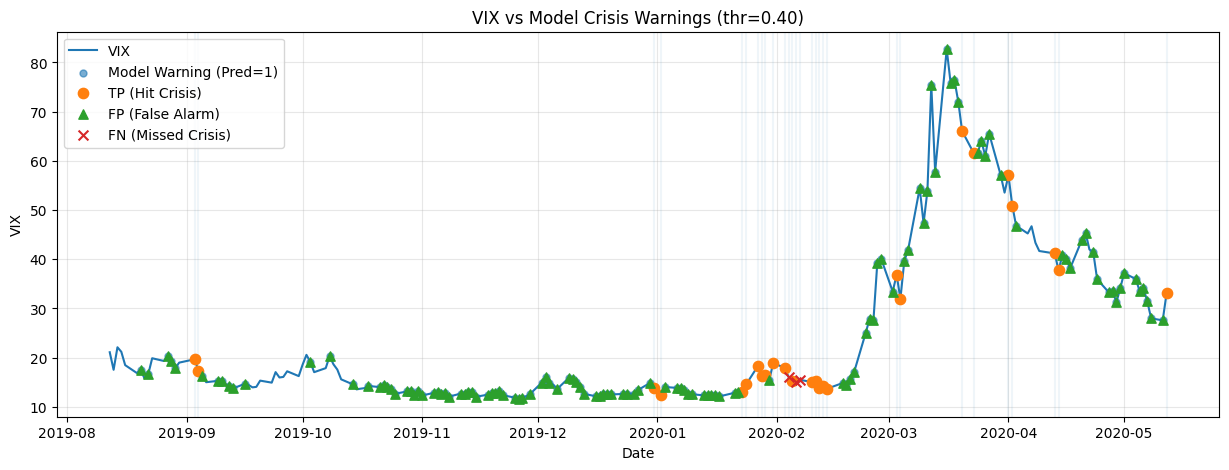

Spike events: 25
Warned before spike: 0.76
Warned same day: 0.76


,spike_date,vix_ret_pct,warned_before,warned_same_day
0,2019-08-12,17.362276,False,False
1,2019-08-14,26.141551,False,False
2,2019-08-23,19.124703,True,False
3,2019-09-24,14.352779,False,False
4,2019-10-01,14.285713,False,False
5,2019-10-02,10.775862,False,False
6,2019-10-08,13.549832,False,True
7,2019-12-02,18.145800,True,True
8,2019-12-09,16.446401,True,True
9,2019-12-30,10.349958,True,True


In [ ]:
val_result_df = get_val_result_df(model, val_loader, val_indices, end_dates_idx, device, final_best_t)
vix_merged_df = plot_vix_model_warnings(vix_raw, val_result_df, title_suffix=f"(thr={final_best_t:.2f})")
lead_df = evaluate_warning_leadtime(vix_raw, val_result_df, vix_spike_pct=10.0, lookback_days=3)
display(lead_df.head(20))


In [ ]:
def build_false_positive_analysis_table(val_result_df, vix_raw, market_proxy_series=None):
    """
    market_proxy_series: 예) SPY 종가 또는 시장지수 (optional)
    """
    df = val_result_df.copy()
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()

    fp = df[df["case"] == "FP"].copy().sort_values("date")

    # VIX 붙이기
    vix = vix_raw.copy()
    vix.index = pd.to_datetime(vix.index).normalize()
    vix = vix.sort_index()

    vix_df = vix.to_frame("VIX")
    vix_df["VIX_ret_pct"] = vix_df["VIX"].pct_change() * 100
    vix_df["VIX_3d_ret_pct"] = vix_df["VIX"].pct_change(3) * 100

    fp = fp.merge(vix_df.reset_index().rename(columns={"index": "date"}), on="date", how="left")

    # (선택) 시장지수 붙이기
    if market_proxy_series is not None:
        mkt = market_proxy_series.copy()
        mkt.index = pd.to_datetime(mkt.index).normalize()
        mkt = mkt.sort_index()

        mkt_df = mkt.to_frame("MKT")
        mkt_df["MKT_ret_pct"] = mkt_df["MKT"].pct_change() * 100
        mkt_df["MKT_3d_ret_pct"] = mkt_df["MKT"].pct_change(3) * 100

        fp = fp.merge(mkt_df.reset_index().rename(columns={"index": "date"}), on="date", how="left")

    # 간단 태깅 규칙 (노이즈 vs 불안 선행 가능성)
    def tag_row(r):
        if pd.notna(r.get("VIX_ret_pct", np.nan)) and r["VIX_ret_pct"] >= 5:
            return "VIX_jump_same_day (possibly early stress)"
        if pd.notna(r.get("VIX_3d_ret_pct", np.nan)) and r["VIX_3d_ret_pct"] >= 10:
            return "VIX_uptrend (possibly early warning)"
        return "likely_noise_or_threshold_issue"

    fp["fp_tag"] = fp.apply(tag_row, axis=1)
    return fp
fp_df = build_false_positive_analysis_table(val_result_df, vix_raw)
print("FP count:", len(fp_df))
display(fp_df[["date", "y_prob", "VIX", "VIX_ret_pct", "VIX_3d_ret_pct", "fp_tag"]].head(50))
print(fp_df["fp_tag"].value_counts(dropna=False))


KeyError: 'date'